# Generate a Mock Dataset

Generate a simulated TF dataset as follows:

* Merge the loa photometric + spectroscopic catalogs with the SGA2020 catalog.
* Apply all photometric corrections used in the TF analysis.
* Cross-match with one of the BGS mocks.
* Apply photometric and morphological cuts used in the PV survey for late-type galaxies.
* Generate mock rotational velocities using an inverted TFR best fit from the data.
* Generate mock TFR distances. 

In [1]:
import os
import shutil
import h5py
import fitsio
import pickle
import healpy as hp
import pandas as pd
import numpy as np
import scipy as sp

from itertools import groupby

from csaps import csaps
from scipy.interpolate import PchipInterpolator, UnivariateSpline
from scipy.stats import binned_statistic
from scipy.odr import ODR, Model, RealData
from scipy.spatial import KDTree

#- Global file path for PV analysis.
#  Set to the NERSC folder /global/cfs/cdirs/desi/science/td/pv by default.
#  Set it to something else if working offline.
# pvpath = '/global/cfs/cdirs/desi/science/td/pv'
pvpath = '/Users/sbenzvi/Documents/DESI/pv'
mockpath = os.path.join(pvpath, 'mocks')
tfmockpath = os.path.join(mockpath, 'DR2/TF_mocks/full_mocks')

from corner import corner
from hyperfit.linfit import LinFit
from hyperfit_v3 import MultiLinFit
from line_fits import hyperfit_line_multi

#- Path to TF_mocks: code for Blanton's k-corrections.
import sys
sys.path.append(tfmockpath)
import TF_photoCorrect as tfpc

from astropy import constants as const
from astropy import units as u
from astropy.io import fits
from astropy.table import Table
from astropy.cosmology import Planck18, FlatLambdaCDM, units
from astropy.coordinates import SkyCoord, Distance

from tqdm import tqdm
from glob import glob

from sklearn.covariance import EllipticEnvelope
from scipy.stats import chi2, norm

import matplotlib as mpl
import matplotlib.colors as colors
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

/var/folders/_q/fz6mqjy17zz9cs9ng5q0hq_m0000gq/T/ipykernel_43192/724432531.py:16: DeprecationWarning: `scipy.odr` is deprecated as of version 1.17.0 and will be removed in SciPy 1.19.0. Please use `https://pypi.org/project/odrpack/` instead.
  from scipy.odr import ODR, Model, RealData


In [2]:
mpl.rc('font', size=11)

In [3]:
#- Version info for mocks
tfr_version = 'v5a'
use_iron_mocks = False
use_loa_mocks = True
mock_version = 'v2.0'
mock_subversion = '8'

### Set up the Cosmology

Use a flat-$\Lambda$CDM fiducial cosmology with $H_0\equiv100$ km/s/Mpc and $\Omega_m=0.3151$.

In [4]:
h = 1
cosmology = FlatLambdaCDM(H0=100*h, Om0=0.3151)

### Ellipse Fit Outlier Cut

Use this ellipse factor to decide where to define outliers in the TF sample. This is motivated by a $\chi^2$ search performed by Sara Moore using DR1 data.

In [5]:
ellipse_sigma = 2.86

### Utility Functions

In [6]:
def downsample(mock: pd.DataFrame, size: int=100) -> pd.DataFrame:
    """Randomly downsample a mock catalog, without replacement, to some size.

    Parameters
    ----------
    mock: pandas.DataFrame
        Pandas table with a mock catalog.
    size: int
        Size of the final downsampled catalog.

    Returns
    -------
    newmock: pandas.DataFrame
        Downsampled Pandas table.
    """
    Nmock = len(mock)
    idx_downsample = np.random.choice(Nmock, size, replace=False)
    return mock.iloc[idx_downsample]

def profile_histogram(x, y, xbins, yerr=None, weights=None, median=False, weighted=False):
    """Compute a profile histogram from scattered data.
    
    Parameters
    ----------
    x : list or ndarray
        Ordinates (independent variable).
    y : list or ndarray
        Coordinates (dependent variable).
    xbins : list or ndarray
        Bin edges for the independent variable.
    yerr : list or ndarray
        Uncertainties on the dependent variable. Assumed independent.
    weights : list or ndarray
        If not None (and weighted=True), will use this instead of yerr to weight 
        the summary statistics.
    median : bool
        If true, compute median as central value; else, the (weighted) mean.
    weighted : bool
        Weight the summary statistics, either by the uncertainty in y or the 
        provided weights.
        
    Returns
    -------
    N : ndarray
        Unweighted counts per bin.
    h : ndarray
        Summary statistic (mean or median) of independent variable per bin.
    e : ndarray
        Uncertainty on the summary statistic per bin.
    """
    
    N = binned_statistic(x, y, bins=xbins, statistic='count').statistic

    if weighted:
        if (yerr is None) and (weights is None):
            raise ValueError('need to define either yerr or weights if using weighted fit.')

        if weights is None:
            # weight based on yerr
            w = 1/yerr**2
        else:
            w = weights
        W, H, E = binned_statistic(x, [w, w*y, w*y**2], bins=xbins, statistic='sum').statistic
        h = H/W
        e = 1/np.sqrt(W)
    else:
        mean, mean2 = binned_statistic(x, [y, y**2], bins=xbins, statistic='mean').statistic
        h = mean
        e = np.sqrt((mean2 - mean**2) / (N - 1))

    if median:
        h = binned_statistic(x, y, bins=xbins, statistic='median').statistic
    
    return N, h, e

## Current Y3 TFR Best Fit

TF Y3 best-fit parameters and covariances, corresponding to v3 of the TF Y3 catalog. This comes from the TFR calibration using redshift bins of width 0.005 from z=0.01 to z=0.10. We fit for 

$$
M_r = a \log_{10}{\left(\frac{V_\mathrm{rot}}{V_0}\right)} + b_{i}
$$

with intrinsic scatter $\sigma$ along the magnitude axis. 

The parameter vector includes the TFR slope $a$, bin intercepts $\{b_i\}$, and intrinsic scatter $\sigma$.

In [7]:
tfrcatfile = os.path.join(pvpath, f'tfgalaxies/Y3/DESI-DR2_TF_pv_cat_{tfr_version}.fits')
tfrcat = Table.read(tfrcatfile)
tfr_params = fits.open(tfrcatfile)
#- Set minimum velocity uncertainty to 7 km/s.
# lowverr = tfrcat['V_0p4R26_ERR'] < 7.
# tfrcat['V_0p4R26_ERR'][lowverr] = 7.

tfrcat['logv_rot'] = np.log10(tfrcat['V_0p4R26'])
tfrcat['logv_rot_err'] = 0.434*tfrcat['V_0p4R26_ERR'] / tfrcat['V_0p4R26']

# tfrcat = tfrcat['Z_DESI', 'Z_DESI_CMB', 'D26', 'R_MAG_SB26_CORR', 'R_MAG_SB26_ERR_CORR', 'R_ABSMAG_SB26', 'R_ABSMAG_SB26_ERR', 'LOGDIST', 'LOGDIST_ERR','GOOD_MORPH', 'MU_ZCMB', 'MU_ZCMB_ERR', 'V_0p4R26', 'V_0p4R26_ERR', 'logv_rot', 'logv_rot_err', 'MAIN'].to_pandas()

#- Added Aug 2026: cut the data to match the mocks, which only go out to z_cos=0.11
tfrcat = tfrcat[tfrcat['Z_DESI_CMB'] < 0.11]

tfrcat = tfrcat.to_pandas()
tfrcat

,SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,...,R_ABSMAG_SB26_TF,R_ABSMAG_SB26_TF_ERR,R_ABSMAG_SB26_TF_ERR_STAT,R_ABSMAG_SB26_TF_ERR_SYS,MU_TF,MU_TF_ERR,LOGDIST,LOGDIST_ERR,logv_rot,logv_rot_err
0,32.0,b'SGA-2020 32',b'PGC2644444',2644444,212.024610,62.838580,b'Spiral',26.250000,0.375837,0.602560,...,-21.801200,0.418677,0.223884,0.353788,37.276935,0.439097,0.032496,0.087820,2.384384,0.032746
1,38.0,b'SGA-2020 38',b'SDSSJ140638.88+393138.1',3558705,211.661940,39.527234,b'Spiral',81.629997,0.353183,0.377572,...,-19.815891,0.452439,0.282482,0.353419,36.759429,0.471756,0.061988,0.094351,2.086716,0.041143
2,53.0,b'SGA-2020 53',b'2MASXJ17023385+3640545',3389283,255.641060,36.681793,b'Spiral',61.060001,0.358096,0.583445,...,-21.749568,0.427264,0.239607,0.353756,38.093227,0.437457,-0.115125,0.087492,2.376266,0.034936
3,55.0,b'SGA-2020 55',b'PGC1203947',1203947,199.730613,1.726355,b'Spiral',159.490005,0.351560,0.510505,...,-18.573453,0.423284,0.232942,0.353423,35.723934,0.436959,0.000053,0.087392,1.914694,0.034302
4,63.0,b'SGA-2020 63',b'PGC1602229',1602229,234.875113,19.697652,b'Spiral',168.559998,0.465586,0.338844,...,-18.806583,0.397901,0.182825,0.353412,35.186272,0.430091,0.114574,0.086019,1.949055,0.027013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30576,5002778.0,b'SGA-2020 5002778',b'DR8-1826p530-1933',-1,182.843943,53.019404,b'Irregular',8.349643,0.663867,0.574916,...,-19.682258,0.411331,0.269726,0.310549,36.510792,0.425610,-0.097366,0.085122,2.055426,0.041024
30577,5002787.0,b'SGA-2020 5002787',b'DR8-1570p537-1063',-1,157.200413,53.704932,b'Irregular',68.160271,0.477373,0.468995,...,-18.953926,0.509320,0.403634,0.310623,36.266792,0.521269,-0.104890,0.104254,1.953434,0.060626
30578,5002789.0,b'SGA-2020 5002789',b'DR8-1961p537-1955',-1,196.389449,53.770799,b'Irregular',101.259689,0.531610,0.930730,...,-16.214428,1.937981,1.912554,0.312904,34.048611,1.938773,0.263557,0.387755,1.544990,0.224772
30579,5002867.0,b'SGA-2020 5002867',b'DR8-2624p570-1299',-1,262.255562,56.939815,b'Irregular',139.680054,0.405085,0.370397,...,-18.382363,0.646952,0.567146,0.311275,35.792734,0.654001,0.136846,0.130800,1.857438,0.082555


In [8]:
# with open('/global/cfs/cdirs/desi/science/td/pv/tfgalaxies/Y3/cov_ab_loa_jointTFR_ellipse_v3.pickle', 'rb') as tfr_file:
#     cov_ab, tfr_samples, logV0, zmin, zmax, dz, zbins = pickle.load(tfr_file)

# tf_par = np.median(tfr_samples, axis=1)
# a, b, sigma = tf_par[0], tf_par[1:-1], tf_par[-1]

# zmin, zmax, dz = 0.01, 0.105, 0.005
# zbins = np.arange(zmin, zmax, dz)
# logV0 = 2.163980618632272

In [9]:
with open(os.path.join(pvpath, f'tfgalaxies/Y3/cov_ab_loa_jointTFR_ellipse_{tfr_version}_spirals.pickle'), 'rb') as tfr_file:
    cov_ab, tfr_samples, logV0, zmin, zmax, dz, zbins = pickle.load(tfr_file)

tf_par = np.median(tfr_samples, axis=1)
a, b, sigma = tf_par[0], tf_par[1:-1], tf_par[-1]

logV0, a, b, sigma

(np.float64(2.1667289487278083),
 np.float64(-6.7403640586997575),
 array([12.98903967, 13.62239741, 14.10317369, 14.4913052 , 14.80381234,
        15.10047052, 15.33333108, 15.56779361, 15.77608285, 15.95838413,
        16.15621086, 16.3138689 , 16.4668066 , 16.60612397, 16.76159022,
        16.86797767, 17.03151095, 17.16760446]),
 np.float64(0.3530473926237314))

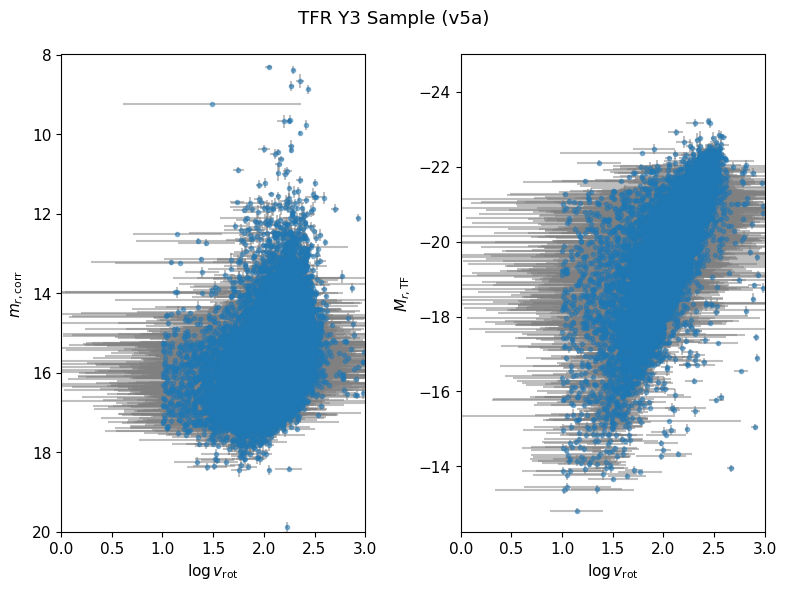

In [10]:
fig, axes = plt.subplots(1,2, figsize=(8,6), tight_layout=True, sharex=True)

ax = axes[0]
ax.errorbar(tfrcat['logv_rot'], tfrcat['R_MAG_SB26_CORR'],
             xerr=tfrcat['logv_rot_err'],
             yerr=tfrcat['R_MAG_SB26_ERR_CORR'],
             fmt='.', 
             alpha=0.5, 
             ecolor='gray')

ax.set(xlim=(0,3),
       xlabel=r'$\log{v_\mathrm{rot}}$',
       ylabel=r'$m_{r,\mathrm{corr}}$',
       ylim=(20,8))

ax = axes[1]
ax.errorbar(tfrcat['logv_rot'], tfrcat['R_ABSMAG_SB26'],
             xerr=tfrcat['logv_rot_err'],
             yerr=tfrcat['R_ABSMAG_SB26_ERR'],
             fmt='.', 
             alpha=0.5, 
             ecolor='gray')

ax.set(xlim=(0,3),
       xlabel=r'$\log{v_\mathrm{rot}}$',
       ylabel=r'$M_{r,\mathrm{TF}}$',
       ylim=(-12.25, -25))

fig.suptitle(f'TFR Y3 Sample ({tfr_version})')
fig.set_facecolor('none');
# fig.savefig('tfr_y1_sample.png', dpi=180);

## Loa Data + SGA Catalog

Follow the procedure used in FP mock generation: read in loa data relevant for the TFR for cross-matching to the BGS mocks, producing a simulated set with realistic galaxy observables.

Here we merge the fullsweep and loa specprod catalogs to reproduce cuts when cross-matching with the mocks.

As a final step, get any missing SGA data directly from the SGA 2020 catalog.

In [11]:
#- Read in the loa fullsweep and specprod catalogs.
sw_keys = ['targetid', 'survey', 'program', 'healpix', 'target_ra', 'target_dec',
           'z', 'zerr', 'zwarn', 'inbasiccuts', 'has_corrupt_phot',
           'mag_g', 'mag_r', 'mag_z',
           'mag_g_err', 'mag_r_err', 'mag_z_err',
           'morphtype', 'sersic', 'BA_ratio',
           'circ_radius', 'circ_radius_err', 'uncor_radius', 'SGA_id', 'radius_SB25']

loasweep = os.path.join(pvpath, 'redshift_data/Y3/loa_fullsweep_catalogue_z015.csv')
loa = pd.read_csv(loasweep, usecols=sw_keys)

#- Read in the spectroscopic production table generated by Caitlin Ross.
sp_keys = ['targetid', 'survey', 'program', 'healpix', 
           'deltachi2']

loaspec = os.path.join(pvpath, 'redshift_data/Y3/specprod_loa_healpix_z015.csv')
loasp = pd.read_csv(loaspec, usecols=sp_keys)

#- Cross-match the catalogs.
loa = pd.merge(loa, loasp, 
                left_on=['targetid', 'survey', 'program', 'healpix'],
                right_on=['targetid', 'survey', 'program', 'healpix'], how='inner')

#- Object selection from the spectro pipeline:
#  1. Valid SGA ID, which implicitly enforces a size selection.
#  2. Delta-chi2 > 25.
#  3. No redrock warnings.
select = (loa['SGA_id'] > 0) & \
         (loa['deltachi2'] >= 25) & \
         (loa['zwarn'] == 0)

loa = loa.drop(loa[~select].index)

#- Read the SGA catalog and match on SGA_ID.
#  This is needed to access R_26 and other quantities at the mag 26 isophote.
# sgafile = '/global/cfs/cdirs/cosmo/data/sga/2020/SGA-2020.fits'
sgafile = os.path.join(pvpath, 'redshift_data/Y3/SGA-2020.fits')
sgacat = Table.read(sgafile, 'ELLIPSE')
sgacat.rename_column('SGA_ID', 'SGA_id')
sgacat.rename_column('RA', 'SGA_ra')
sgacat.rename_column('DEC', 'SGA_dec')
sgacat = sgacat['SGA_ra', 'SGA_dec', 'SGA_id', 'BA', 'D26', 'G_MAG_SB26', 'G_MAG_SB26_ERR', 'R_MAG_SB26', 'R_MAG_SB26_ERR', 'Z_MAG_SB26', 'Z_MAG_SB26_ERR'].to_pandas()
sgacat = sgacat.drop(sgacat[sgacat['R_MAG_SB26'] < 0].index)

loa = pd.merge(loa, sgacat, how='inner', on=['SGA_id'])

In [12]:
#- Drop NaN
loa = loa.dropna()
loa

,survey,program,healpix,targetid,target_dec,target_ra,z,zerr,zwarn,morphtype,...,SGA_ra,SGA_dec,BA,D26,G_MAG_SB26,G_MAG_SB26_ERR,R_MAG_SB26,R_MAG_SB26_ERR,Z_MAG_SB26,Z_MAG_SB26_ERR
0,main,bright,16789,39627328233407054,-19.185317,10.855016,0.107766,0.000008,0,SER,...,10.855016,-19.185317,0.512632,0.722513,16.983086,0.019287,16.223730,0.022714,15.622272,0.024195
1,main,bright,16832,39627328233410197,-19.143422,10.962909,0.105902,0.000016,0,SER,...,10.962909,-19.143422,0.854210,0.538702,16.618881,0.004184,15.931306,0.004947,15.399325,0.005905
2,main,bright,16832,39627328241799327,-19.151702,11.482420,0.083850,0.000015,0,SER,...,11.482420,-19.151702,0.306469,0.576062,17.450583,0.025181,16.617634,0.027905,15.975766,0.029473
3,main,bright,16725,39627328405380909,-19.192709,21.901771,0.044200,0.000003,0,SER,...,21.901771,-19.192709,0.376867,0.568998,16.446529,0.007890,15.687962,0.008825,15.101869,0.010002
4,main,bright,36460,39627328640255525,-19.247678,36.522337,0.055596,0.000019,0,SER,...,36.522337,-19.247678,0.459508,0.554353,17.570637,0.026897,16.707050,0.028544,16.060282,0.029269
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
227433,main,dark,8128,2852683992006656,78.716726,134.046537,0.079701,0.000004,0,DEV,...,134.046537,78.716726,0.868890,0.608948,16.382385,0.007190,15.720165,0.007679,15.365249,0.015038
227434,main,bright,27676,39627914534193541,5.138895,183.141382,0.124945,0.000040,0,DEV,...,183.141382,5.138895,0.505039,0.509869,17.829351,0.041672,17.218763,0.038816,16.487047,0.048348
227435,main,bright,9790,39633072966077479,39.717466,235.717134,0.104020,0.000031,0,DEV,...,235.717134,39.717466,0.539554,0.897598,17.249649,0.011744,14.459822,0.096703,16.628946,0.018688
227436,main,dark,9790,39633072966077479,39.717466,235.717134,0.104007,0.000017,0,DEV,...,235.717134,39.717466,0.539554,0.897598,17.249649,0.011744,14.459822,0.096703,16.628946,0.018688


### Keep only Galaxy Centers

The loa catalog may include some off-axis measurements of SGA galaxies that pass the spectroscopic cuts. Remove them with a cone-angle cut, comparing the SGA centers (from Tractor) to the target RA, Dec in DESI. The cut is

$$
\frac{\angle(\mathbf{r}_\mathrm{SGA}, \mathbf{r}_\mathrm{fiber})}{D_{26}/2} < 0.1
$$

See details in Kelly's [SGA selection notebook for loa](https://github.com/DESI-UR/DESI_SGA/blob/master/TF/Y3/v3/loa_rot_vel.ipynb).

Note that requiring a nonzero $m_{r,\mathrm{SB_{26}}}$ may remove all spectra not measured on galaxy centers, making this cut redundant.

In [13]:
coords_sga = SkyCoord(ra=loa['SGA_ra'], dec=loa['SGA_dec'], unit='degree')
coords_loa = SkyCoord(ra=loa['target_ra'], dec=loa['target_dec'], unit='degree')
sep2d = coords_loa.separation(coords_sga)
select = (2*sep2d.to_value('arcmin') / loa['D26']) < 0.1

loa = loa.drop(loa[~select].index)

In [14]:
loa

,survey,program,healpix,targetid,target_dec,target_ra,z,zerr,zwarn,morphtype,...,SGA_ra,SGA_dec,BA,D26,G_MAG_SB26,G_MAG_SB26_ERR,R_MAG_SB26,R_MAG_SB26_ERR,Z_MAG_SB26,Z_MAG_SB26_ERR
0,main,bright,16789,39627328233407054,-19.185317,10.855016,0.107766,0.000008,0,SER,...,10.855016,-19.185317,0.512632,0.722513,16.983086,0.019287,16.223730,0.022714,15.622272,0.024195
1,main,bright,16832,39627328233410197,-19.143422,10.962909,0.105902,0.000016,0,SER,...,10.962909,-19.143422,0.854210,0.538702,16.618881,0.004184,15.931306,0.004947,15.399325,0.005905
2,main,bright,16832,39627328241799327,-19.151702,11.482420,0.083850,0.000015,0,SER,...,11.482420,-19.151702,0.306469,0.576062,17.450583,0.025181,16.617634,0.027905,15.975766,0.029473
3,main,bright,16725,39627328405380909,-19.192709,21.901771,0.044200,0.000003,0,SER,...,21.901771,-19.192709,0.376867,0.568998,16.446529,0.007890,15.687962,0.008825,15.101869,0.010002
4,main,bright,36460,39627328640255525,-19.247678,36.522337,0.055596,0.000019,0,SER,...,36.522337,-19.247678,0.459508,0.554353,17.570637,0.026897,16.707050,0.028544,16.060282,0.029269
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
227433,main,dark,8128,2852683992006656,78.716726,134.046537,0.079701,0.000004,0,DEV,...,134.046537,78.716726,0.868890,0.608948,16.382385,0.007190,15.720165,0.007679,15.365249,0.015038
227434,main,bright,27676,39627914534193541,5.138895,183.141382,0.124945,0.000040,0,DEV,...,183.141382,5.138895,0.505039,0.509869,17.829351,0.041672,17.218763,0.038816,16.487047,0.048348
227435,main,bright,9790,39633072966077479,39.717466,235.717134,0.104020,0.000031,0,DEV,...,235.717134,39.717466,0.539554,0.897598,17.249649,0.011744,14.459822,0.096703,16.628946,0.018688
227436,main,dark,9790,39633072966077479,39.717466,235.717134,0.104007,0.000017,0,DEV,...,235.717134,39.717466,0.539554,0.897598,17.249649,0.011744,14.459822,0.096703,16.628946,0.018688


## BGS Mock Catalog

Read in one of the mock catalog files and cross-match to loa.

In [15]:
#- There are 25 BGS mocks and (usually) 27 realizations per mock.
#  Pick one, it doesn't matter which.
if use_iron_mocks:
    mockfiles = sorted(glob(os.path.join(pvpath, f'mocks/BGS_base/{mock_version}/iron/BGS_PV_AbacusSummit_base*.hdf5')))
elif use_loa_mocks:
    mockfiles = sorted(glob(os.path.join(pvpath, f'mocks/DR2/BGS_base/{mock_version}/loa/BGS_PV_AbacusSummit_base_*.hdf5')))
else:
    mockfiles = sorted(glob(os.path.join(mockpath, f'DR2/BGS_base/{mock_version}/data/BGS_PV_AbacusSummit_base*.hdf5')))
n_mock = len(mockfiles)
# mockfile = mockfiles[np.random.randint(n_mock)]
mockfile = mockfiles[0]

print(f'Picked mock file {mockfile}.')

Picked mock file /Users/sbenzvi/Documents/DESI/pv/mocks/DR2/BGS_base/v2.0/loa/BGS_PV_AbacusSummit_base_c000_ph000_r000_zsnap0.20_zmax0.11.dat.hdf5.


In [16]:
#- Fill the catalog as a dictionary and convert to a Pandas table.
#  Here we follow the I/O from the FP generator (thanks Cullan).
mock = {}
with h5py.File(mockfile, 'r') as f:
    for key in f.keys():
        if key == 'vel':
            #- Pack the galaxy velocities into labeled vx, vy, vz
            mock['vx'] = f['vel'][:,0]
            mock['vy'] = f['vel'][:,1]
            mock['vz'] = f['vel'][:,2]
        else:
            mock[key] = f[key][()]

        # convert strings to unicode
        if key == 'survey' or key == 'program':
            mock[key] = mock[key].astype('U')

    #- Convert to a pandas table
    mock = pd.DataFrame.from_dict(mock)

    #- Merge with loa on 4 keywords.
    #  NOTE: targetid, survey, program, and healpix are MISSING from the mocks in DR2/BGS_base/v2.0/data!
    if use_iron_mocks or use_loa_mocks:
        mock = mock.merge(loa, how='inner', on=['targetid', 'survey', 'program', 'healpix'])
    else:
        #- Cross-match on 3D position
        #  Q: use zcos from mock, or zobs?
        coords_mock = SkyCoord(ra=mock['ra'], dec=mock['dec'], distance=cosmology.comoving_distance(mock['zcos']), unit=['degree', 'degree', 'Mpc'])
        coords_loa = SkyCoord(ra=loa['target_ra'], dec=loa['target_dec'], distance=cosmology.comoving_distance(loa['z']), unit=['degree', 'degree', 'Mpc'])
        idx, sep, sep3d = coords_loa.match_to_catalog_3d(coords_mock)
        mock = pd.concat([mock.loc[idx].reset_index(drop=True), loa.reset_index(drop=True)], axis=1)

In [17]:
mock.keys()

Index(['Y1_COMP', 'Y3_COMP', 'Y5', 'abs_mag', 'app_mag', 'col', 'col_obs',
       'dec', 'halo_ind', 'halo_mass', 'healpix', 'is_cen', 'is_res',
       'program', 'ra', 'survey', 'targetid', 'vx', 'vy', 'vz', 'zcos', 'zobs',
       'target_dec', 'target_ra', 'z', 'zerr', 'zwarn', 'morphtype', 'sersic',
       'mag_g', 'mag_g_err', 'mag_r', 'mag_r_err', 'mag_z', 'mag_z_err',
       'uncor_radius', 'BA_ratio', 'circ_radius', 'circ_radius_err', 'SGA_id',
       'radius_SB25', 'inbasiccuts', 'has_corrupt_phot', 'deltachi2', 'SGA_ra',
       'SGA_dec', 'BA', 'D26', 'G_MAG_SB26', 'G_MAG_SB26_ERR', 'R_MAG_SB26',
       'R_MAG_SB26_ERR', 'Z_MAG_SB26', 'Z_MAG_SB26_ERR'],
      dtype='str')

In [18]:
np.sum(mock['sersic'] < 2), np.sum(mock['morphtype'] == 'SER')

(np.int64(230712), np.int64(419191))

In [19]:
mock

,Y1_COMP,Y3_COMP,Y5,abs_mag,app_mag,col,col_obs,dec,halo_ind,halo_mass,...,SGA_ra,SGA_dec,BA,D26,G_MAG_SB26,G_MAG_SB26_ERR,R_MAG_SB26,R_MAG_SB26_ERR,Z_MAG_SB26,Z_MAG_SB26_ERR
0,0.924658,0.924658,True,-21.681203,15.980767,0.959772,0.985186,-3.081162,2,1.706458e+13,...,114.900371,31.668484,0.537164,0.692125,17.112272,0.009347,16.094082,0.010237,15.360697,0.011305
1,0.970588,0.970588,True,-20.488670,17.171757,0.813491,0.833173,-0.196342,874,7.761420e+11,...,149.533385,23.161163,0.308653,0.547537,17.914038,0.022277,17.179199,0.028566,16.564869,0.030887
2,0.987654,0.987654,True,-21.318251,16.328807,0.938828,0.961914,0.371128,1233,4.557725e+12,...,122.508695,50.204015,0.709269,0.480229,17.399311,0.021687,16.377272,0.024560,15.676418,0.037593
3,0.966887,0.966887,True,-21.133204,16.525630,0.826597,0.846668,-5.154562,1403,3.844856e+12,...,21.691356,10.616310,0.272239,0.753816,17.289972,0.028538,16.374771,0.031623,15.607842,0.028915
4,0.974522,0.974522,True,-21.633502,16.028507,0.982113,1.008027,-2.117007,1483,5.106086e+12,...,142.375072,38.072669,0.637648,0.674974,17.016966,0.006935,15.993052,0.007676,15.463270,0.011889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
459156,0.974359,0.974359,True,-20.706135,16.942413,0.462727,0.474658,0.071354,3748,1.910828e+12,...,192.090666,6.539140,0.645062,0.393766,17.555260,0.011820,17.109577,0.011328,16.764923,0.015794
459157,0.761589,0.960265,True,-20.610928,17.058295,1.048685,1.075785,0.297476,3762,1.702029e+12,...,189.253700,67.878455,0.305225,0.617594,17.894402,0.030981,16.853640,0.039738,16.079979,0.050015
459158,0.000000,0.986207,True,-21.439198,16.217645,0.796503,0.815184,-9.626423,565,1.245539e+14,...,172.893967,34.089594,0.476927,0.645820,16.977552,0.016585,16.176828,0.017137,15.622334,0.021072
459159,0.000000,0.992958,True,-20.744806,16.908841,1.048842,1.074031,-3.069424,2099,1.012549e+14,...,196.016265,2.792503,0.296177,0.556502,17.636858,0.044574,16.588472,0.050492,15.830099,0.054869


### Apply TF Selection Cuts to the Mocks

Here apply the late-type galaxy cuts defined in *Target Selection for the DESI Peculiar Velocity Survey*, C. Saulder+, MNRAS 525:1106, 2023. Note that several cuts are the complement of the early-type cuts for the FP sample.

In [20]:
mock_selection = {
    'initial catalog' : 0,
    'basic cuts' : 0,
    # '0.03 < z < 0.105' : 0,
    # 'b/a < cos(25°)' : 0,
    'morphtype' : 0,
    # 'NaN' : 0
}

#- Apply target selection
print(f'Size of cross-matched loa+mock catalog ..{len(mock):.>20d}')
mock_selection['initial catalog'] = len(mock)

#- Drop data that doesn't pass the photometric cuts
select = (mock['inbasiccuts'] == 0) | (mock['has_corrupt_phot'] == 1)
mock = mock.drop(mock[select].index)
mock_selection['basic cuts'] = len(mock)
print(f'Size after photometric cuts .........{len(mock):.>20d}')

#- Redshift range cut: remove?
# select = (mock['zobs'] > 0.03) & (mock['zobs'] <= 0.105)
# mock = mock[select]
# mock_selection['0.03 < z < 0.105'] = len(mock)
# print(f'Redshift selection: 0.03 < z < 0.105 {len(mock):.>20d}')

### July 2026: commenting this cut, because we find that large B/A objects exist in the data
###
# #- B/A ratio cut:
# select = mock['BA_ratio'] < np.cos(np.radians(25))
# mock = mock[select]
# mock_selection['b/a < cos(25°)'] = len(mock)
# print(f'Ratio b/a < cos(25 deg) .............{len(mock):.>20d}')

#- Morphology cuts:
select = (mock['morphtype'] == 'EXP') | ((mock['morphtype'] == 'SER') & (mock['sersic'] <= 2))
mock = mock[select]
mock_selection['morphtype'] = len(mock)
print(f'Morphology cuts: ....................{len(mock):.>20d}')

# #- Drop any rows with NaN
# mock = mock.dropna()
# mock_selection['NaN'] = len(mock)
# print(f'Drop NaN ............................{len(mock):.>20d}')

Size of cross-matched loa+mock catalog ................459161
Size after photometric cuts .......................459012
Morphology cuts: ..................................230980


/var/folders/_q/fz6mqjy17zz9cs9ng5q0hq_m0000gq/T/ipykernel_43192/3164248107.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=45, ha='right')


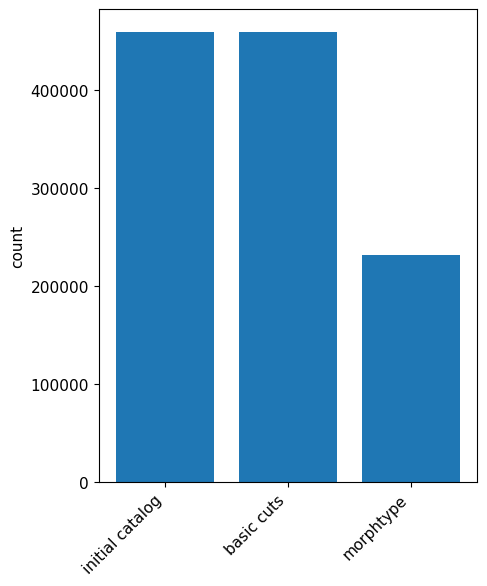

In [21]:
names = list(mock_selection.keys())
values = list(mock_selection.values())

fig, ax = plt.subplots(1, 1, figsize=(5,6), tight_layout=True)
bars = ax.bar(names, values)
ax.set_xticklabels(names, rotation=45, ha='right')
# ax.bar_label(bars, fmt='%d')
ax.set(ylabel='count');#, yscale='log', ylim=[1e3,1.2e4])
fig.set_facecolor('none')
# fig.savefig('tfr_mock_cuts.png', dpi=150)

(array([ 1.03455032,  2.70916335,  4.31062635,  6.95708967,  8.21109007,
        10.8889034 , 15.22565476, 16.0015675 , 14.59604206, 15.97021749,
        14.84945464, 14.05786689, 13.05466658, 11.56292861, 10.18091568,
         8.9661028 ,  7.78002743,  6.7298021 ,  5.50715172,  4.64241395,
         3.67840115,  3.08536346]),
 array([0.   , 0.005, 0.01 , 0.015, 0.02 , 0.025, 0.03 , 0.035, 0.04 ,
        0.045, 0.05 , 0.055, 0.06 , 0.065, 0.07 , 0.075, 0.08 , 0.085,
        0.09 , 0.095, 0.1  , 0.105, 0.11 ]),
 [<matplotlib.patches.Polygon at 0x436c50e10>])

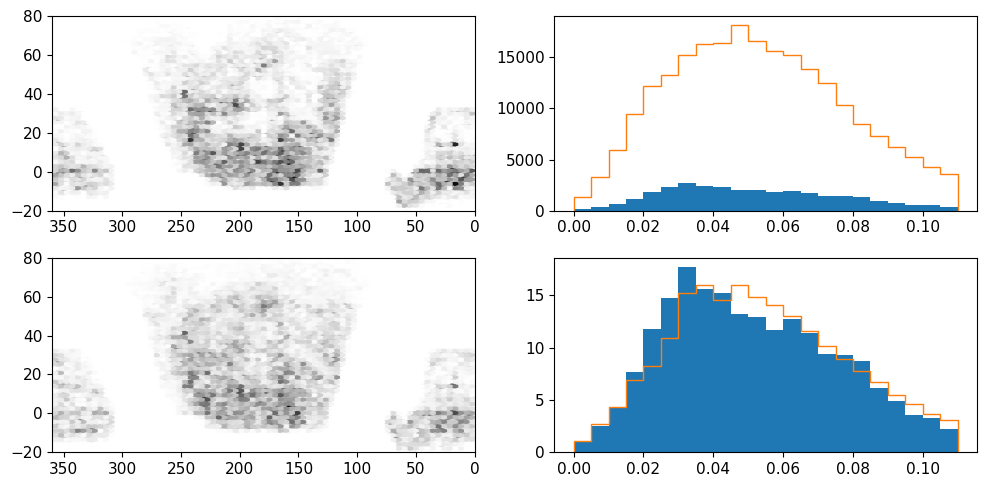

In [22]:
fix, axes = plt.subplots(2, 2, figsize=(10,5), tight_layout=True)

ax = axes[0,0]
ax.hexbin(tfrcat['RA'], tfrcat['DEC'], gridsize=75, cmap='Greys')
ax.set(xlim=(360,0),
       ylim=(-20,80))

ax = axes[0,1]
ax.hist(tfrcat['Z_DESI'], bins=np.arange(0, 0.115, 0.005))
ax.hist(mock['z'], bins=np.arange(0, 0.115, 0.005), histtype='step')

select = mock['Y3_COMP'] > 0

ax = axes[1,0]
ax.hexbin(mock['target_ra'], mock['target_dec'], gridsize=75, cmap='Greys')
ax.set(xlim=(360,0),
       ylim=(-20,80))

ax = axes[1,1]
ax.hist(tfrcat['Z_DESI'], bins=np.arange(0, 0.115, 0.005), density=True)
ax.hist(mock['z'][select], bins=np.arange(0, 0.115, 0.005), histtype='step', density=True)

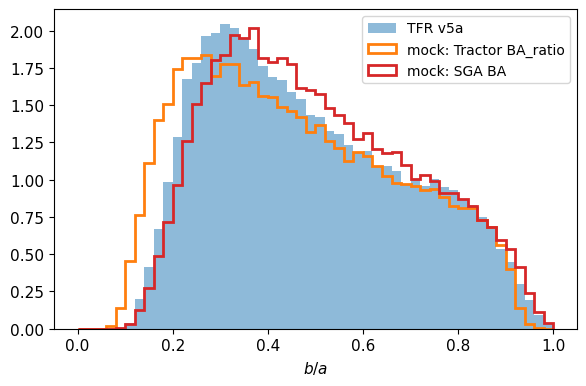

In [23]:
fig, ax = plt.subplots(1,1, figsize=(6,4), tight_layout=True)
ax.hist(tfrcat['BA'], bins=np.arange(0,1.02,0.02), density=True, label=f'TFR {tfr_version}', alpha=0.5)
ax.hist(mock['BA_ratio'], bins=np.arange(0,1.02,0.02), histtype='step', lw=2, label='mock: Tractor BA_ratio', density=True)
ax.hist(mock['BA'], bins=np.arange(0,1.02,0.02), histtype='step', color='tab:red', lw=2, label='mock: SGA BA', density=True)

ax.set(xlabel='$b/a$')
ax.legend(fontsize=10);

## Apply Dust and K-corrections

There are four photometric corrections that need to be applied.

1. N vs. S imaging catalog photometric systematics.
<!-- 2. $k$-corrections to $z=0.1$. -->
3. Global Milky Way dust corrections using the maps from Zhou+, 2024.
4. Per-galaxy internal dust corrections based on the galaxies' inclination angles.

The corrections, applied to the $r$-band magnitudes, are summed as

$$
A_\mathrm{sys} + A_k + A_\mathrm{MW} + A_\mathrm{dust}
$$

### Imaging Systematics

In [24]:
#- Apply imaging survey systematics: compute photometric system (N or S)
#  Note that we need the RA,Dec of the *data*, not the mocks, because the corrections
#  are applied to the observed magnitudes from SGA (MAG_R_SB26, etc.).
c = SkyCoord(mock['target_ra'], mock['target_dec'], unit='degree')
isnorth = (c.galactic.b > 0) & (mock['target_dec'] > 32.375)
mock['photsys'] = 'S'
mock.loc[isnorth, 'photsys'] = 'N'

#- Adjust northern photometry to DECaLS
Asys, Asys_err = tfpc.BASS_corr(mock['photsys'])
mock['A_SYS'] = Asys
mock['A_SYS_ERR'] = Asys_err

In [25]:
print(len(mock), len(mock.dropna()))
mock = mock.dropna()

230980 230980


### K Correction (we do not apply this correction)

In [26]:
# #- This is based on the kcorrect package by Blanton (https://kcorrect.readthedocs.io/)
# #  Note that we need the RA,Dec of the *data*, not the mocks, because the corrections
# #  are applied to the observed magnitudes from SGA (MAG_R_SB26, etc.).
# select = mock['z'] > 0

# kc = tfpc.k_corr(mock['z'][select], 
#                 [mock['G_MAG_SB26'][select],     mock['R_MAG_SB26'][select],     mock['Z_MAG_SB26'][select]], 
#                 [mock['G_MAG_SB26_ERR'][select], mock['R_MAG_SB26_ERR'][select], mock['Z_MAG_SB26_ERR'][select]], 
#                 z_corr=0.1)

# Ak = np.zeros((len(mock), 3))
# Ak[select] = kc

### MW Dust Correction

In [27]:
#- Compute MW dust corrections
#  Note that we need the RA,Dec of the *data*, not the mocks, because the corrections
#  are applied to the observed magnitudes from SGA (MAG_R_SB26, etc.).
# dustmap = '/global/cfs/cdirs/desi/public/papers/mws/desi_dust/y2/v1/maps/desi_dust_gr_512.fits'
dustmap = os.path.join(pvpath, 'redshift_data/Y3/desi_dust_gr_512.fits')
ebv = Table.read(dustmap)
Adust, Adust_err = tfpc.MW_dust(mock['target_ra'].values, mock['target_dec'].values, ebv)

#- Mask out NaNs
for i, band in enumerate('grz'):
    isnan_gal = np.isnan(Adust[i])
    if np.any(isnan_gal):
        logging.info(f'Removing NaN for MW dust correction, band {band}')
        Adust[i][isnan_gal] = 0
        Adust_err[i][isnan_gal] = 0

/Users/sbenzvi/Documents/DESI/pv/TF_photoCorrect.py:90: UserWarning: Warning: converting a masked element to nan.
  EBV_err[i] = ebv_map['EBV_GR_ERR'][i_ebv]


#### Apply MW Dust and Imaging Systematics Corrections Prior to Internal Dust Correction

In [28]:
#- Apply MW dust, k-corrections, and photometric systematic corrections to the data.
for i, band in enumerate('GRZ'):
    mock[f'{band}_MAG_SB26_tmp'] = mock[f'{band}_MAG_SB26'] - Adust[i] + Asys #+ Ak[:,i]
    mock[f'{band}_MAG_SB26_ERR_tmp'] = np.sqrt(mock[f'{band}_MAG_SB26_ERR']**2 + Adust_err[i]**2 + Asys_err**2)

In [29]:
print(len(mock), len(mock.dropna()))
mock = mock.dropna()

230980 177184


### Internal Dust Correction 

Correct m_r for the internal galactic dust, assuming that as we look through higher inclinations we're viewing the galaxy through its dust lanes. Details in [this notebook by Kelly](https://github.com/DESI-UR/DESI_SGA/blob/master/TF/Y3/TF_loa_internal-dustCorr.ipynb).

0 G
30581
[0.03211346 0.01312952 0.01081464 0.01176858 0.01320512 0.01396285
 0.01635604 0.01802642]
Best fit:     [-1.00902706  0.48383257]
uncertainty:  [0.1625223  0.08878771]
1 R
30581
[0.03272942 0.01352486 0.01112081 0.01221973 0.01321478 0.01426996
 0.01768292 0.019015  ]
Best fit:     [-0.71194798  0.34083796]
uncertainty:  [0.17734313 0.09575319]
2 Z
30581
[0.03237913 0.01370934 0.0116298  0.01266571 0.01410591 0.01487102
 0.01804213 0.01969562]
Best fit:     [-0.38339594  0.18681833]
uncertainty:  [0.14872846 0.07864312]


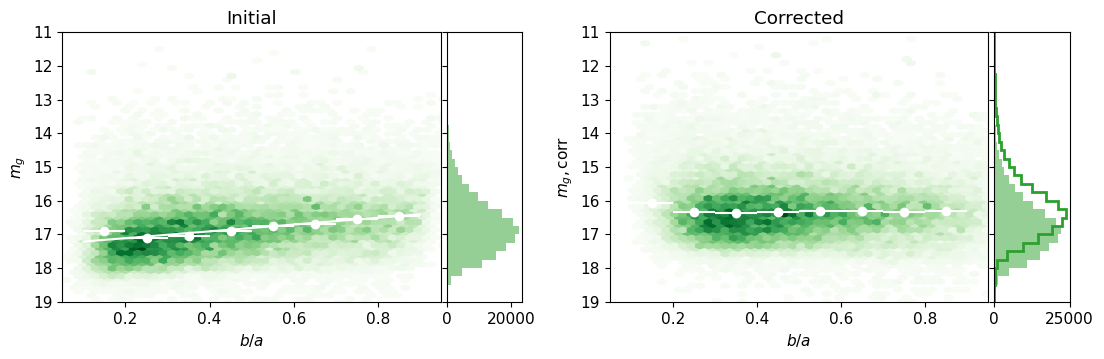

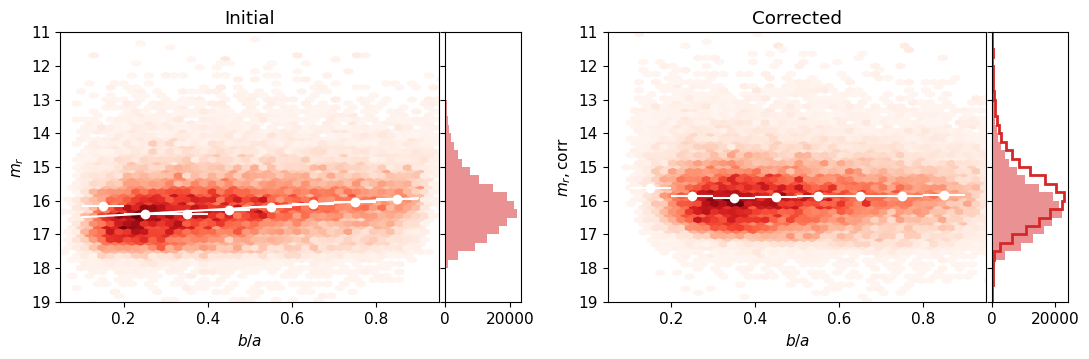

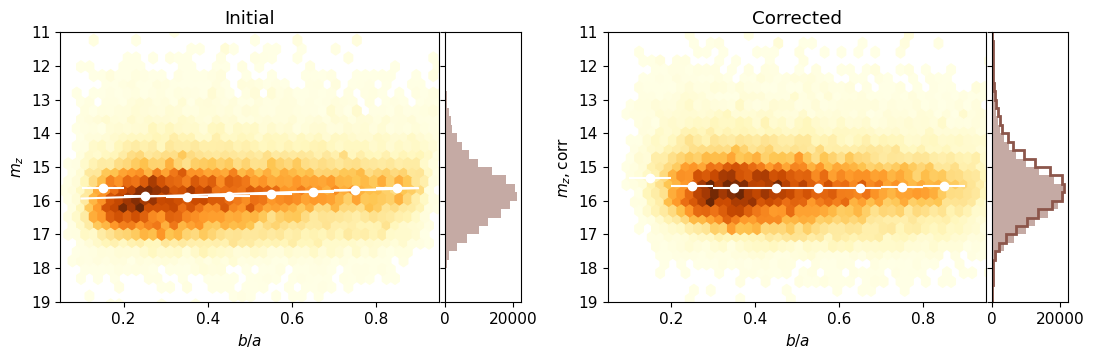

In [30]:
#- Kelly applies an empirical fit to the internal dust in each galaxy. Steps:
#   1. Apply "known" corrections (k-correction, MW dust).
#   2. Fit m_r_corr (corrected) vs spiral b/a
#   3. Zero out this linear dependence.

#- Set up a binned data set and perform the fit
m_bins = np.arange(10.75, 20, 0.25)
ba_bins = np.arange(0.1,1,0.1)
ba = 0.5*(ba_bins[1:] + ba_bins[:-1])
ba_err = 0.5*np.diff(ba_bins)

colors = { 'G':['Greens', 'tab:green'],
           'R':['Reds', 'tab:red'],
           'Z':['YlOrBr', 'tab:brown'] }
A_int_coeff = {}
A_int_coeff_err = {}

#- If true, downsample the mock to the size of the TFR catalog.
#  Then use this to compute the dust correction coefficients.
downsample_mock = True

#- To use B/A from Tractor: use "BA_ratio"
#  To use B/A from the SGA: use "BA"
ba_variable = 'BA' # 'BA_ratio'

for i, band in enumerate('GRZ'):
    print(i, band)

    if downsample_mock:
        Ntfr = len(tfrcat)
        magtab = downsample(mock[[ba_variable, f'{band}_MAG_SB26_tmp']], Ntfr)
    else:
        magtab = mock[[ba_variable, f'{band}_MAG_SB26_tmp']]
    print(len(magtab))
    
    m_median = np.median(magtab[f'{band}_MAG_SB26_tmp'])
    m_, _, _ = binned_statistic(magtab[ba_variable], magtab[f'{band}_MAG_SB26_tmp'], statistic='median', bins=ba_bins)
    n_bin, _, _ = binned_statistic(magtab[ba_variable], magtab[f'{band}_MAG_SB26_tmp'], statistic='count', bins=ba_bins)
    m_err, _, _ = binned_statistic(magtab[ba_variable], magtab[f'{band}_MAG_SB26_tmp'], statistic='std', bins=ba_bins)
    m_err /= np.sqrt(n_bin)
    print(m_err)

    linear_fit = lambda coeff, x: coeff[0]*x + coeff[1]
    model = Model(linear_fit)
    data = RealData(ba, m_ - m_median, sx=ba_err, sy=m_err)
    odr = ODR(data, model, beta0=[1, 1])

    result = odr.run()
    coeff = result.beta
    coeff_err = result.sd_beta
    A_int_coeff[band] = coeff
    A_int_coeff_err[band] = coeff_err
    
    print('Best fit:    ', coeff)
    print('uncertainty: ', coeff_err)

    fig, axes = plt.subplots(1, 5, figsize=(13,3.5),
                             gridspec_kw={'hspace':0.03, 'wspace':0.0295, 'width_ratios':[5,1,1,5,1]})
    # fig, axes = plt.subplots(1,2, figsize=(11,3.5), tight_layout=True, sharex=True)#, sharey=True)
    ax = axes[0]
    ax.hexbin(mock['BA_ratio'], mock[f'{band}_MAG_SB26_tmp'], gridsize=(45,40), cmap=colors[band][0], mincnt=2)
    # ax.scatter(mock['BA_ratio'], mock[f'{band}_MAG_SB26_tmp'], color=colors[band], alpha=0.01)
    ax.errorbar(ba, m_, xerr=ba_err, yerr=m_err, fmt='o', color='white')
    ax.plot(ba_bins, coeff[0]*ba_bins + coeff[1] + m_median, color='white')
    ax.set(xlim=(0.05,0.95),
           ylim=(19, 11),
           ylabel=f'$m_{{{band.lower()}}}$',
           xlabel='$b/a$',
           title='Initial');

    ax = axes[1]
    ax.hist(mock[f'{band}_MAG_SB26_tmp'], bins=m_bins, orientation='horizontal', color=colors[band][1], alpha=0.5)
    ax.set(ylim=(19, 11), yticklabels=[])

    #- Compute the internal dust correction
    A_int_band, A_int_err_band = tfpc.internal_dust(mock[ba_variable].values, coeff, coeff_err)

    ax = axes[2]
    ax.set_axis_off()
    
    ax = axes[3]
    # ax.scatter(mock['BA_ratio'], mock[f'{band}_MAG_SB26_tmp'] - A_int, color=colors[band], alpha=0.01)
    ax.hexbin(mock[ba_variable], mock[f'{band}_MAG_SB26_tmp'] - A_int_band, gridsize=(45,40), cmap=colors[band][0], mincnt=2)
    m_, _, _ = binned_statistic(mock[ba_variable], mock[f'{band}_MAG_SB26_tmp'] - A_int_band, statistic='median', bins=ba_bins)
    ax.errorbar(ba, m_, xerr=ba_err, yerr=m_err, fmt='o', color='white')
    ax.set(xlim=(0.05,0.95),
           ylim=(19, 11),
           ylabel=rf'$m_{{{band.lower()}}},\mathrm{{corr}}$',
           xlabel='$b/a$',
           title='Corrected')
    
    # fig.savefig('tfr_mock_internal_dust_correction.png', dpi=150);
    
    #- Update the r-band magnitudes
    mock[f'{band}_MAG_SB26_CORR'] = mock[f'{band}_MAG_SB26_tmp'] - A_int_band
    mock[f'{band}_MAG_SB26_ERR_CORR'] = np.sqrt(mock[f'{band}_MAG_SB26_ERR_tmp']**2 + A_int_err_band**2)

    mock[f'A_INT_{band}'] = A_int_band
    mock[f'A_INT_ERR_{band}'] = A_int_err_band

    ax = axes[4]
    ax.hist(mock[f'{band}_MAG_SB26_CORR'], bins=m_bins, orientation='horizontal', histtype='step', lw=2, color=colors[band][1])
    ax.hist(mock[f'{band}_MAG_SB26_tmp'], bins=m_bins, orientation='horizontal', color=colors[band][1], alpha=0.5)
    ax.set(ylim=(19, 11), yticklabels=[])

In [31]:
print(len(mock), len(mock.dropna()))
mock = mock.dropna()

177184 177184


#### Sanity Check: Internal Dust Correction from the TFR Catalog

In [32]:
# with open('loa_internalDust_nokcorr_mcmc.pickle', 'rb') as f:
#     dust_data = pickle.load(f)

# for i, band in enumerate('grz'):
#     dust_mcmc_samples_band = dust_data[2*i]
#     int_dust_coeffs_band = np.median(dust_mcmc_samples_band, axis=1)
#     int_dust_coeffs_err_band = [np.std(dust_mcmc_samples_band[0][(-1.5 < dust_mcmc_samples_band[0]) & (dust_mcmc_samples_band[0] < 0)])]
#     A_int_band, A_int_err_band = tfpc.internal_dust(mock['BA_ratio'].values, int_dust_coeffs_band, int_dust_coeffs_err_band)

#### Before/After All Magnitude Corrections

[Text(0.5, 0, '$m$'),
 (20.0, 11.0),
 Text(0, 0.5, 'count'),
 Text(0.5, 1.0, 'Mock magnitudes (corrected)')]

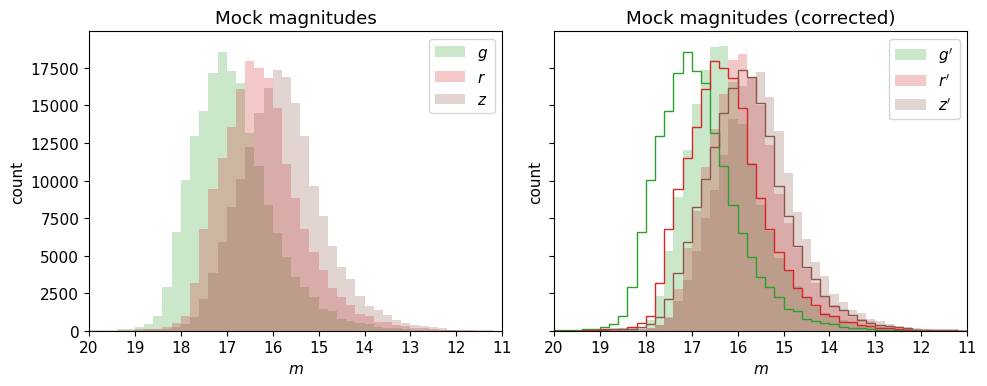

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(10,4), sharex=True, sharey=True, tight_layout=True)

ax = axes[0]
for band, col in zip('GRZ', ['tab:green', 'tab:red', 'tab:brown']):
    ax.hist(mock[f'{band}_MAG_SB26'], bins=np.arange(11, 20.2, 0.2), color=col, alpha=0.25, label=rf'${band.lower()}$')
ax.legend(loc='upper right')
ax.set(xlabel=r'$m$',
       xlim=(20,11),
       ylabel='count',
       title='Mock magnitudes')

ax = axes[1]
for band, col in zip('GRZ', ['tab:green', 'tab:red', 'tab:brown']):
    ax.hist(mock[f'{band}_MAG_SB26'], bins=np.arange(11, 20.2, 0.2), histtype='step', color=col)
    ax.hist(mock[f'{band}_MAG_SB26_CORR'], bins=np.arange(11, 20.2, 0.2), color=col, alpha=0.25, label=rf"${band.lower()}'$")
ax.legend(loc='upper right')
ax.set(xlabel=r'$m$',
       xlim=(20,11),
       ylabel='count',
       title='Mock magnitudes (corrected)')

### Compare Mock and TFR Catalog Magnitudes

If the TFR catalog magnitudes are, on average, less bright than the mock magnitudes, shift and scale the mock distribution to match the data.

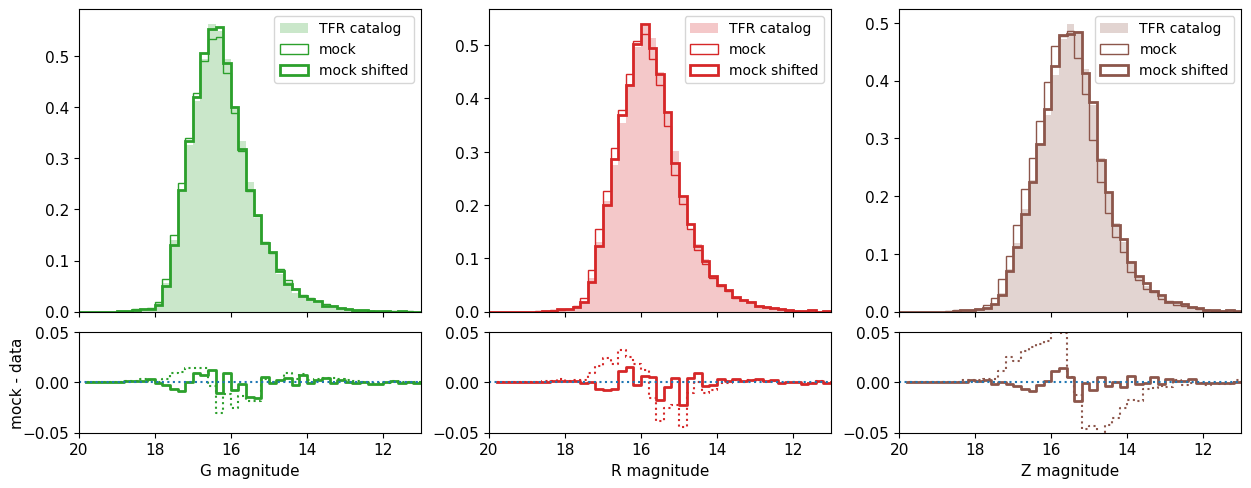

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(15,5.5), sharex=True,
                         gridspec_kw={'height_ratios':[3,1], 'hspace':0.1})

for i, (band, color) in enumerate(zip('GRZ', ['tab:green', 'tab:red', 'tab:brown'])):
    ax = axes[0,i]
    n_data, bins, _ = ax.hist(tfrcat[f'{band}_MAG_SB26_CORR'], bins=np.arange(11, 20.2, 0.2), density=True, color=color, alpha=0.25, label='TFR catalog')
    n_mock, bins, _ = ax.hist(mock[f'{band}_MAG_SB26_CORR'], bins=np.arange(11, 20.2, 0.2), histtype='step', lw=1, color=color, density=True, label='mock')

    tfravg = np.average(tfrcat[f'{band}_MAG_SB26_CORR'])
    tfrstd = np.std(tfrcat[f'{band}_MAG_SB26_CORR'])
    mockavg = np.average(mock[f'{band}_MAG_SB26_CORR'])
    mockstd = np.std(mock[f'{band}_MAG_SB26_CORR'])
    mock[f'{band}_MAG_SB26_CORR'] = (mock[f'{band}_MAG_SB26_CORR'] - mockavg) * tfrstd / mockstd + tfravg
    n_mock_shifted, bins, _ = ax.hist(mock[f'{band}_MAG_SB26_CORR'], bins=np.arange(11, 20.2, 0.2), histtype='step', lw=2, color=color, density=True, label='mock shifted')

    ax.legend(fontsize=10)

    ax = axes[1,i]
    ax.step(bins[:-1], n_mock - n_data, ls=':', color=color)
    ax.step(bins[:-1], n_mock_shifted - n_data, lw=2, color=color)
    ax.axhline(ls=':')
    
    ax.set(xlim=(20, 11),
           xlabel=f'{band} magnitude',
           ylim=(-0.05, 0.05))

    if band=='G':
        ax.set_ylabel('mock - data', labelpad=-2)

#### Shift the Mock Magnitude Uncertainties

Apply a mean shift and scaling to the magnitude uncertainties to match the data.

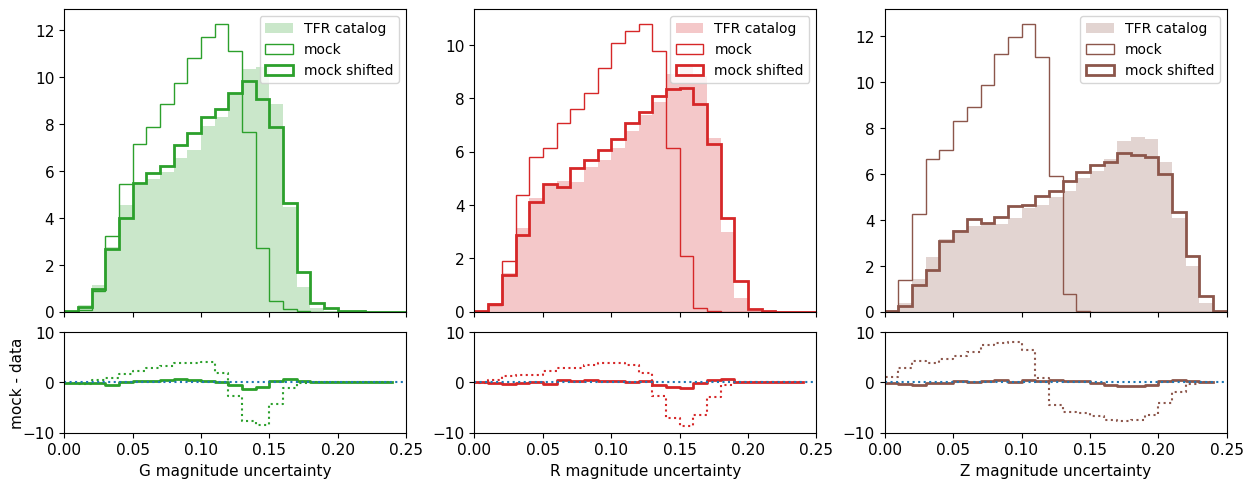

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(15,5.5), sharex=True,
                         gridspec_kw={'height_ratios':[3,1], 'hspace':0.1})

for i, (band, color) in enumerate(zip('GRZ', ['tab:green', 'tab:red', 'tab:brown'])):
    ax = axes[0,i]
    n_data, bins, _ = ax.hist(tfrcat[f'{band}_MAG_SB26_ERR_CORR'], bins=np.arange(0,0.26,0.01), color=color, alpha=0.25, density=True, label='TFR catalog')
    n_mock, bins, _ = ax.hist(mock[f'{band}_MAG_SB26_ERR_CORR'], bins=np.arange(0,0.26,0.01), histtype='step', color=color, density=True, label='mock')

    tfravg = np.average(tfrcat[f'{band}_MAG_SB26_ERR_CORR'])
    tfrstd = np.std(tfrcat[f'{band}_MAG_SB26_ERR_CORR'])
    mockavg = np.average(mock[f'{band}_MAG_SB26_ERR_CORR'])
    mockstd = np.std(mock[f'{band}_MAG_SB26_ERR_CORR'])

    mockerr = (mock[f'{band}_MAG_SB26_ERR_CORR'] - mockavg) / mockstd * tfrstd + tfravg
    mock[f'{band}_MAG_SB26_ERR_CORR'] = mockerr
    n_mock_shifted, bins, _ = ax.hist(mock[f'{band}_MAG_SB26_ERR_CORR'], bins=np.arange(0,0.26,0.01), histtype='step', lw=2, color=color, density=True, label='mock shifted')

    if np.any(mockerr <= 0):
        print(f'mag: {band}: {np.sum(mockerr <= 0)}')
    
    ax.legend(fontsize=10)

    ax = axes[1,i]
    ax.step(bins[:-1], n_mock - n_data, ls=':', color=color)
    ax.step(bins[:-1], n_mock_shifted - n_data, lw=2, color=color)
    ax.axhline(ls=':')
    
    ax.set(xlim=(0, 0.25),
           xlabel=f'{band} magnitude uncertainty',
           ylim=(-10, 10))

    if band=='G':
        ax.set_ylabel('mock - data', labelpad=-2)

### Generate Absolute Magnitudes for TFR Fitting

Procedure:
1. Calculate $M_{r,\mathrm{cos}}$ using $z_\mathrm{cos}$ from the mocks. This explicitly excludes mock peculiar velocities.
1. Compute distance moduli $\mu$ for each *observed* redshift in the mocks, $z_\mathrm{obs}$.
1. Compute $M_{r,\mathrm{obs}}$ using $m_{r,\mathrm{SB26}}$ from cross-matched from data and the generated $\mu$.
1. Scatter $\log{V_\mathrm{rot}}$ by binning the Y3 data in magnitude ($M_{r,\mathrm{cos}}$), computing the $\log{v_\mathrm{rot}}$ CDF in each bin, and randomly sampling new values.

In [36]:
#- Use distmod with cosmological redshifts to compute a "true" absolute magnitude M_r(SB26).
#  Then compute a central value for rotational velocity using this "true" magnitude.
Mr_cos = mock['R_MAG_SB26_CORR'] - cosmology.distmod(mock['zcos']).to_value('mag')
Mg_cos = mock['G_MAG_SB26_CORR'] - cosmology.distmod(mock['zcos']).to_value('mag')
Mz_cos = mock['Z_MAG_SB26_CORR'] - cosmology.distmod(mock['zcos']).to_value('mag')

#- Compute an observed magnitude based on the PVs in the mock catalog.
mu_obs_mock = cosmology.distmod(mock['zobs']).to_value('mag')
mock['MU_OBS_MOCK'] = mu_obs_mock
Mr_obs_mock = (mock['R_MAG_SB26_CORR'] - mu_obs_mock).to_numpy()
Mr_obs_err_mock = mock['R_MAG_SB26_ERR_CORR'].to_numpy()

Mg_obs_mock = (mock['G_MAG_SB26_CORR'] - mu_obs_mock).to_numpy()
Mg_obs_err_mock = mock['G_MAG_SB26_ERR_CORR'].to_numpy()

Mz_obs_mock = (mock['Z_MAG_SB26_CORR'] - mu_obs_mock).to_numpy()
Mz_obs_err_mock = mock['Z_MAG_SB26_ERR_CORR'].to_numpy()

#- Bin R_ABSMAG_SB26. Merge any bins with < 50 datapoints, working from the ends of the magnitude range.
bins = np.arange(-26, -12 + 0.05, 0.05)
M_r_bins = [bins[0]]
for k in np.arange(1, len(bins)):
    select = (tfrcat['R_ABSMAG_SB26'] > M_r_bins[-1]) & (tfrcat['R_ABSMAG_SB26'] <= bins[k])    
    if np.sum(select) >= 50:
        M_r_bins.append(bins[k])
M_r_bins.append(bins[-1])
N_bins = len(M_r_bins)

# print(np.histogram(tfrcat['R_ABSMAG_SB26'], M_r_bins))

#- Loop through the magnitude bins and regenerate log(v_rot) by resampling the data.
#  Try to reduce resampling effects by using a smoothed version of the CDF of log(v_rot).
logvrot_mock = np.zeros_like(Mr_obs_mock)

use_weighted_fit = True

for k in tqdm(np.arange(0, N_bins-1)):
    # # TEST
    # if k > 5*N_bins//9:
    #     break
    
    M_r_min, M_r_max = M_r_bins[k], M_r_bins[k+1]

    #- Select TFR velocity data in this magnitude bin and compute the CDF of log(v_rot).
    i = (tfrcat['R_ABSMAG_SB26'] > M_r_min) & (tfrcat['R_ABSMAG_SB26'] <= M_r_max)
    logvrot_slice = tfrcat['logv_rot'][i].to_numpy()
    logvrot_err_slice = tfrcat['logv_rot_err'][i].to_numpy()

    if use_weighted_fit:
        #- Attempt to build a weighted CDF
        logvrot_bins = np.arange(1, 3.01, 0.01)
        logvrot_pdf_wt, logv_bins = np.histogram(logvrot_slice, bins=logvrot_bins, 
                                                 weights=np.ones_like(logvrot_err_slice)
                                                 # weights=1/logvrot_err_slice**2
                                                )
        logvrot_cdf = np.cumsum(logvrot_pdf_wt) / np.sum(logvrot_pdf_wt)
        
        logvrot_slice = 0.5*(logvrot_bins[1:] + logvrot_bins[:-1])

        #- Keep only the unique elements in the list
        idx = np.cumsum([len(list(g)) for k, g in groupby(logvrot_cdf)])[:-1]
        logvrot_cdf = logvrot_cdf[idx]
        logvrot_slice = logvrot_slice[idx]
        # print(logvrot_cdf.shape, logvrot_slice.shape)
    else:
        #- Default to the unweighted CDF
        logvrot_cdf = np.cumsum(logvrot_slice) / np.sum(logvrot_slice)

    #- Select mock data in this magnitude bin.
    j = (Mr_cos > M_r_min) & (Mr_cos <= M_r_max)
    # j = (Mr_obs_mock > M_r_min) & (Mr_obs_mock <= M_r_max)
    N_mock_slice = np.sum(j)
    un = np.random.uniform(size=N_mock_slice)
    logvrot_mock_slice = csaps(logvrot_cdf, np.sort(logvrot_slice), un).values
    logvrot_mock[j] = logvrot_mock_slice

    #- Apply a velocity cut of 10 to 1000 km/s.
    #  Regenerate any velocities that fall outside the valid range.
    #  Note that an intermediate variable is needed to manage the array slicing.
    bad_vrot = (logvrot_mock[j] < 1) | (logvrot_mock[j] > 3)
    while np.any(bad_vrot):
        N_regen = np.sum(bad_vrot)
        uni = np.random.uniform(size=N_regen)
        logvrot_mock_regen = logvrot_mock[j]
        logvrot_mock_regen[bad_vrot] = csaps(logvrot_cdf, np.sort(logvrot_slice), uni).values
        logvrot_mock[j] = logvrot_mock_regen
        bad_vrot = (logvrot_mock[j] < 1) | (logvrot_mock[j] > 3)

# - Finally, match mock values against the Y3 data to assign uncertainties on logvrot_mock and Mr_obs_mock.
#  Many ways to do this... here just copy the FP approach of grabbing the nearest neighbor in (log v, M_r)
#  from data and taking its uncertainty.
search_tree = KDTree(np.c_[tfrcat['logv_rot'], tfrcat['R_ABSMAG_SB26']])
search_tree.query([1.5, -20])
_, idx = search_tree.query([[x, y] for (x,y) in zip(logvrot_mock, Mr_obs_mock)])

logvrot_err_mock = tfrcat['logv_rot_err'][idx].to_numpy()
Mr_obs_err_mock = mock['R_MAG_SB26_ERR_CORR'].to_numpy()

mock['LOGVROT_MOCK'] = logvrot_mock
mock['LOGVROT_ERR_MOCK'] = logvrot_err_mock
mock['R_ABSMAG_SB26_MOCK'] = Mr_obs_mock
mock['R_ABSMAG_SB26_ERR_MOCK'] = Mr_obs_err_mock
mock['R_ABSMAG_SB26_TRUE'] = Mr_cos

mock['G_ABSMAG_SB26_MOCK'] = Mg_obs_mock
mock['G_ABSMAG_SB26_ERR_MOCK'] = Mg_obs_err_mock
mock['G_ABSMAG_SB26_TRUE'] = Mg_cos

mock['Z_ABSMAG_SB26_MOCK'] = Mz_obs_mock
mock['Z_ABSMAG_SB26_ERR_MOCK'] = Mz_obs_err_mock
mock['Z_ABSMAG_SB26_TRUE'] = Mz_cos

100%|███████████████████████████████████████████| 113/113 [00:00<00:00, 801.32it/s]


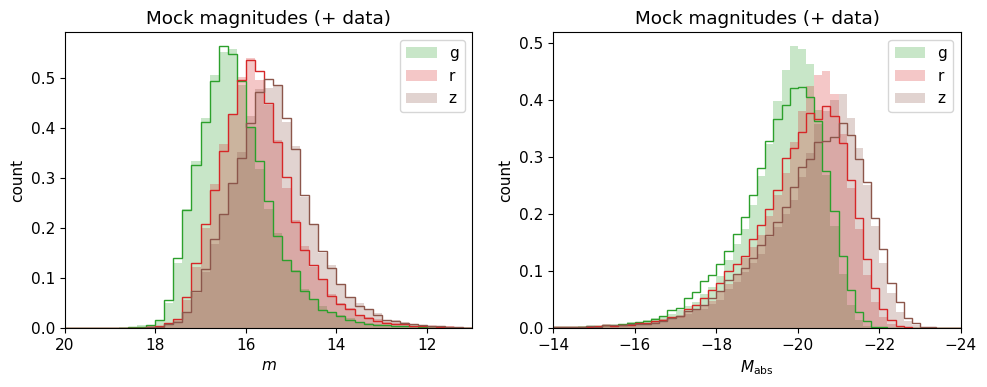

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(10,4), tight_layout=True)

for band, col in zip('GRZ', ['tab:green', 'tab:red', 'tab:brown']):
    ax = axes[0]
    ax.hist(tfrcat[f'{band}_MAG_SB26_CORR'], bins=np.arange(11, 20.2, 0.2), histtype='step', color=col, density=True)
    ax.hist(mock[f'{band}_MAG_SB26_CORR'], bins=np.arange(11, 20.2, 0.2), color=col, alpha=0.26, density=True, label=f'{band.lower()}')

    ax = axes[1]
    # if band == 'R':
    ax.hist(tfrcat[f'{band}_ABSMAG_SB26'], bins=np.arange(-24, -13.8, 0.2), histtype='step', color=col, density=True)
    ax.hist(mock[f'{band}_ABSMAG_SB26_MOCK'], bins=np.arange(-24, -13.8, 0.2), color=col, alpha=0.26, density=True, label=f'{band.lower()}')

ax = axes[0]
ax.legend(loc='upper right')
ax.set(xlabel=r'$m$',
       xlim=(20,11),
       ylabel='count',
       title='Mock magnitudes (+ data)')

ax = axes[1]
ax.legend(loc='upper right')
ax.set(xlabel=r'$M_\mathrm{abs}$',
       xlim=(-14,-24),
       ylabel='count',
       title='Mock magnitudes (+ data)');

In [38]:
np.max(mock['zobs']), np.max(mock['zcos'])

(np.float64(0.11697797083727668), np.float64(0.1099993575859585))

In [39]:
# k = 2*N_bins//3
# M_r_min, M_r_max = M_r_bins[k], M_r_bins[k+1]

# #- Select TFR velocity data in this magnitude bin and compute the CDF of log(v_rot).
# i = (tfrcat['R_ABSMAG_SB26'] > M_r_min) & (tfrcat['R_ABSMAG_SB26'] <= M_r_max)
# logvrot_slice = tfrcat['logv_rot'][i].to_numpy()
# logvrot_err_slice = tfrcat['logv_rot_err'][i].to_numpy()
# logvrot_cdf = np.cumsum(logvrot_slice) / np.sum(logvrot_slice)

# fig, axes = plt.subplots(1, 4, figsize=(16,4), tight_layout=True)

# logvrot_bins = np.arange(1, 3.05, 0.05)

# ax = axes[0]
# ax.hist(logvrot_slice, bins=logvrot_bins)
# ax.set(xlabel=r'$\log{v_\mathrm{rot}}$',
#        ylabel=r'count',
#        title='slice histogram')

# ax = axes[1]
# logvrot_pdf_wt, logv_bins, _ = ax.hist(logvrot_slice, bins=logvrot_bins, weights=1/logvrot_err_slice**2)
# newcdf_wt = np.cumsum(logvrot_pdf_wt) / np.sum(logvrot_pdf_wt)
# ax.set(xlabel=r'$\log{v_\mathrm{rot}}$',
#        title='weighted slice histogram')

# ax = axes[2]
# logvrot_gen = np.random.multivariate_normal(mean=logvrot_slice, cov=np.diag(logvrot_err_slice**2), size=1000).flatten()
# logvrot_pdf_rsmpl, logv_bins, _ = ax.hist(logvrot_gen, bins=logvrot_bins)
# newcdf_rsmpl = np.cumsum(logvrot_pdf_rsmpl) / np.sum(logvrot_pdf_rsmpl)
# ax.set(xlabel=r'$\log{v_\mathrm{rot}}$',
#        title='resampled histogram')

# ax = axes[3]
# ax.plot(np.sort(logvrot_slice), logvrot_cdf, label='unweighted CDF')
# ax.plot(logv_bins[:-1], newcdf_wt, label='weighted CDF')
# ax.plot(logv_bins[:-1], newcdf_rsmpl, label='resampled CDF')
# ax.set(xlabel=r'$\log{v_\mathrm{rot}}$',
#        title='CDF')
# l = ax.legend(loc='upper left', fontsize=10)

#### Apply Outlier Cuts

We define the main cosmology sample to be the objects that fall inside the best-fit ellipse of their respective redshift bins. We read in the best fit ellipse parameters from the DR2 data.

In [40]:
def ellipse_boolean(x, y, mean, cov, n_std=2):
    """
    Determine which points are outside of the ellipse defined by (mean, cov, n_std).

    Parameters
    ----------
    x, y : array-like
        Coordinates of points to test
    mean : array-like, shape (2,)
        Ellipse center
    cov : array-like, shape (2, 2)
        Ellipse covariance matrix
    n_std : float
        Number of standard deviations defining the ellipse

    Returns
    -------
    outlier_boolean : ndarray of bool
        True for points outside the ellipse
    """
    X = np.vstack([x, y]).T
    # mean = np.asarray(mean)
    # cov = np.asarray(cov)

    # Mahalanobis distance squared
    diff = X - mean
    inv_cov = np.linalg.inv(cov)
    mahal_sq = np.einsum('ij,jk,ik->i', diff, inv_cov, diff)

    boolean = mahal_sq > n_std**2
    return ~boolean

def mag_ellipse_boolean(z, x, y, ellipse_vals, n_std, absmag_cat):
    outlier_boolean = np.zeros(len(x), dtype=bool)
    zbin_indices = np.digitize(z, zbins, right=True)
    
    ##first bin and last bin
    for i in {0,len(zbins)}:
        bin_mask = (zbin_indices == i)
        mean = [ellipse_vals[i][0], ellipse_vals[i][1]]
        cov = [[ellipse_vals[i][2], ellipse_vals[i][3]],[ellipse_vals[i][4],ellipse_vals[i][5]]]
        # Outliers within each magnitude bun
        outlier_bin = ellipse_boolean(x[bin_mask], absmag_cat[bin_mask], mean, cov, n_std)
        # Write results back into global array
        outlier_boolean[bin_mask] = outlier_bin
        
    for i in range(1, len(zbins)):
    # for i in range(1, len(zbins)+1):
        bin_mask = (zbin_indices == i)

        mean = [ellipse_vals[i][0], ellipse_vals[i][1]]
        cov = [[ellipse_vals[i][2], ellipse_vals[i][3]],[ellipse_vals[i][4],ellipse_vals[i][5]]]

        # Outliers within each magnitude bun
        outlier_bin = ellipse_boolean(x[bin_mask], y[bin_mask], mean, cov, n_std)

        # Write results back into global array
        outlier_boolean[bin_mask] = outlier_bin
    return outlier_boolean

def plot_ellipse(mean, cov, ax, n_std=2.0, **kwargs):
    """
    Draw a confidence ellipse from mean and covariance.
    n_std=2 ~ 95% for 2D
    """
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]

    angle = np.degrees(np.arctan2(*eigvecs[:,0][::-1]))

    width, height = 2 * n_std * np.sqrt(eigvals)

    ellipse = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=angle,
        **kwargs
    )
    ax.add_patch(ellipse)

In [41]:
#### Read in the best-fit ellipse parameters
ellipse_params = Table.read(os.path.join(pvpath, 'tfgalaxies/Y3/TF_Y3_ellipse_fit_mr_0p01-0p1.fits'))

#### Plot $M_{R,\mathrm{SB26}}$ for Mocks and TFR Data

Make a side-by-side comparison of the (downsampled) mock catalog and Y3 data.

Apply the quality cuts equally to both.

In [42]:
ellipse_params

MU_X,MU_Y,COV_XX,COV_XY,COV_YX,COV_YY
float64,float64,float64,float64,float64,float64
1.746169300025869,-17.053005468905017,0.09237935176378967,-0.4595510336910638,-0.4595510336910638,3.221883658174334
1.8698084781096351,14.917331962021475,0.04176331481567276,-0.216259708690195,-0.216259708690195,1.5519001341058674
1.9567095361169766,14.964271903651541,0.037022649884749376,-0.1923159378057387,-0.1923159378057387,1.301584129920726
1.9950237124265633,15.201336616952144,0.02945450752277639,-0.15380786073593453,-0.15380786073593453,1.0628013321666934
2.025561294576511,15.3820344361714,0.025126134432927497,-0.12574775401888924,-0.12574775401888924,0.8559709434425611
2.058123544687169,15.488489575386964,0.021861038823214097,-0.1091007862809282,-0.1091007862809282,0.7314278540029436
2.0913986379001765,15.559786188717014,0.019622356120592977,-0.0885959198533237,-0.0885959198533237,0.5842173509120691
2.121302798729019,15.618391791065545,0.017388810281697652,-0.07622618233374538,-0.07622618233374538,0.5004769028523691
2.1314517049120614,15.749899707864492,0.017905395245818044,-0.07898364471770228,-0.07898364471770228,0.49304939848012463


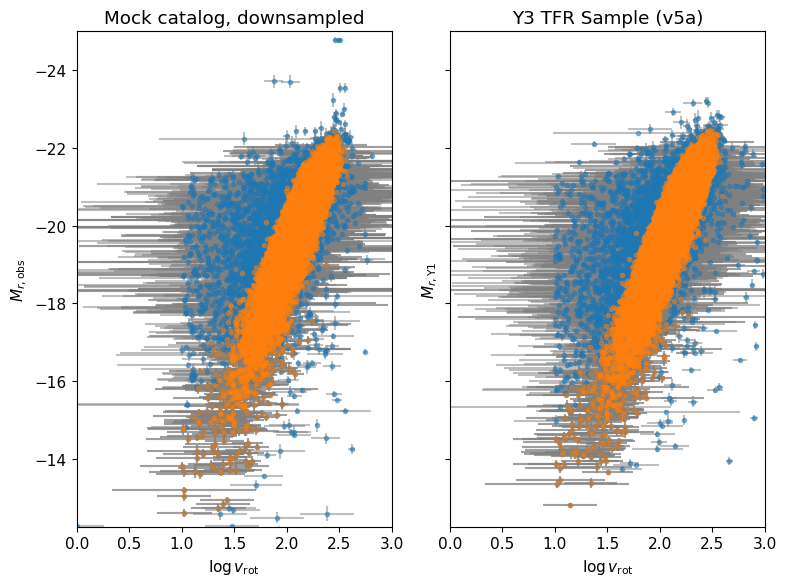

In [43]:
#- Plot Mr vs log(v_rot) for the various steps in the calculation.

fig, axes = plt.subplots(1,2, figsize=(8,6), tight_layout=True, sharex=True, sharey=True)

Ntfr = len(tfrcat)
mock_downsample = downsample(mock, Ntfr)

ax = axes[0]
ax.errorbar(mock_downsample['LOGVROT_MOCK'], mock_downsample['R_ABSMAG_SB26_MOCK'],
            xerr=mock_downsample['LOGVROT_ERR_MOCK'],
            yerr=mock_downsample['R_ABSMAG_SB26_ERR_MOCK'],
            fmt='.', 
            alpha=0.5, 
            ecolor='gray')


idx_mock_good = mag_ellipse_boolean(mock_downsample['zobs'], mock_downsample['LOGVROT_MOCK'], mock_downsample['R_MAG_SB26_CORR'],
                                    ellipse_params, n_std=ellipse_sigma, absmag_cat=mock_downsample['R_ABSMAG_SB26_MOCK'])

ax.errorbar(mock_downsample['LOGVROT_MOCK'][idx_mock_good], mock_downsample['R_ABSMAG_SB26_MOCK'][idx_mock_good],
             xerr=mock_downsample['LOGVROT_ERR_MOCK'][idx_mock_good],
             yerr=mock_downsample['R_ABSMAG_SB26_ERR_MOCK'][idx_mock_good],
             fmt='.', 
             alpha=0.5, 
             ecolor='gray')

ax.set(xlim=(0,3),
       xlabel=r'$\log{v_\mathrm{rot}}$',
       ylabel=r'$M_{r,\mathrm{obs}}$',
       ylim=(-12.25, -25),
       title=r'Mock catalog, downsampled')

ax = axes[1]
ax.errorbar(tfrcat['logv_rot'], tfrcat['R_ABSMAG_SB26'],
             xerr=tfrcat['logv_rot_err'],
             yerr=tfrcat['R_ABSMAG_SB26_ERR'],
             fmt='.', 
             alpha=0.5, 
             ecolor='gray')

# idx_tfr_goodv = alex_cuts_velocity(tfrcat, logv_name='logv_rot', distmod_name='MU_ZCMB')
# idx_tfr_notdwarf = alex_cuts_dwarf(tfrcat, rmag_name='R_MAG_SB26_CORR', distmod_name='MU_ZCMB')
# idx_tfr_good = idx_tfr_goodv & idx_tfr_notdwarf
idx_tfr_good = mag_ellipse_boolean(tfrcat['Z_DESI_CMB'], tfrcat['logv_rot'], tfrcat['R_MAG_SB26_CORR'],
                                   ellipse_params, n_std=ellipse_sigma, absmag_cat=tfrcat['R_ABSMAG_SB26'])

ax.errorbar(tfrcat['logv_rot'][idx_tfr_good], tfrcat['R_ABSMAG_SB26'][idx_tfr_good],
             xerr=tfrcat['logv_rot_err'][idx_tfr_good],
             yerr=tfrcat['R_ABSMAG_SB26_ERR'][idx_tfr_good],
             fmt='.', 
             alpha=0.5, 
             ecolor='gray')

ax.set(xlim=(0,3),
       xlabel=r'$\log{v_\mathrm{rot}}$',
       ylabel=r'$M_{r,\mathrm{Y1}}$',
       ylim=(-12.25, -25),
       title=f'Y3 TFR Sample ({tfr_version})');

fig.set_facecolor('none');
# fig.savefig('tfr_mock_mr_vs_logv.png', dpi=150);

In [44]:
mpl.rc('font', size=12)

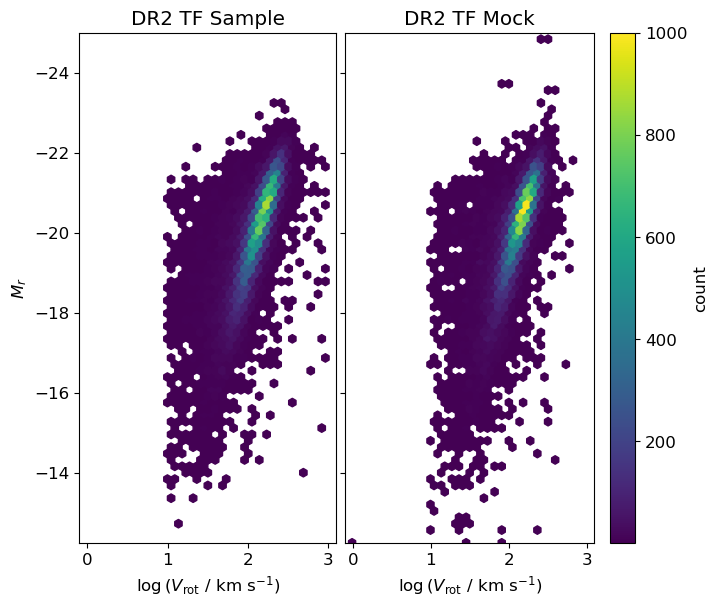

In [45]:
fig, axes = plt.subplots(1,2, figsize=(7,6), sharex=True, sharey=True,
                         gridspec_kw={'wspace':0.03, 'width_ratios':[0.825,1]})

ax = axes[0]
ax.hexbin(tfrcat['logv_rot'], tfrcat['R_ABSMAG_SB26'],
          cmap='viridis', mincnt=1, 
          vmin=1, vmax=1e3,
          gridsize=(35,40), extent=(-0.1, 3.1, -25, -12.25))
ax.set(xlim=(-0.1,3.1),
       xlabel=r'$\log{(V_\mathrm{rot}~/~\mathrm{km~s}^{-1})}$',
       ylabel=r'$M_{r}$',
       ylim=(-12.25, -25),
       title=f'DR2 TF Sample')# ({tfr_version})');

# _log_v_rot = np.arange(-0.1, 3.05, 0.05)
# b0 = -5.7
# a0 = a
# ax.plot(_log_v_rot, b0 + a0*_log_v_rot, ls='--', color='tab:red')

ax = axes[1]
h = ax.hexbin(mock_downsample['LOGVROT_MOCK'], mock_downsample['R_ABSMAG_SB26_MOCK'],
              cmap='viridis', mincnt=1, 
              vmin=1, vmax=1e3,
              gridsize=(35,40), extent=(-0.1, 3.1, -25, -12.25))
cb = fig.colorbar(h, ax=ax, label='count')

ax.set(xlim=(-0.1,3.1),
       xlabel=r'$\log{(V_\mathrm{rot}~/~\mathrm{km~s}^{-1})}$',
       # ylabel=r'$M_{r,\mathrm{Y3}}$',
       ylim=(-12.25, -25),
       title=f'DR2 TF Mock')

# _log_v_rot = np.arange(-0.1, 3.05, 0.05)
# b0 = -5.7
# a0 = a
# ax.plot(_log_v_rot, b0 + a0*_log_v_rot, ls='--', color='tab:red')

fig.subplots_adjust(left=0.1, right=0.925, top=0.95, bottom=0.1)
# fig.savefig('TF_mock_dr2_relation.png', dpi=200)

mpl.rc('font', size=11);

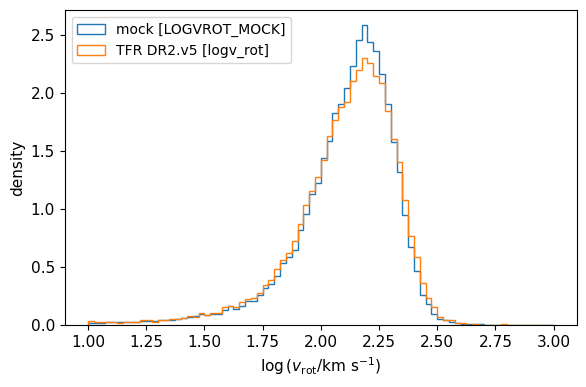

In [46]:
fig, ax = plt.subplots(1,1, figsize=(6,4), tight_layout=True)
ax.hist(mock['LOGVROT_MOCK'], bins=np.arange(1, 3.025, 0.025), density=True, histtype='step', label='mock [LOGVROT_MOCK]')
ax.hist(tfrcat['logv_rot'], bins=np.arange(1, 3.025, 0.025), density=True, histtype='step', label='TFR DR2.v5 [logv_rot]')
ax.set(ylabel='density',
       xlabel=r'$\log{(v_\mathrm{rot}/\mathrm{km~s^{-1}})}$')
ax.legend(loc='upper left', fontsize=10);

#### Apply Quality Cuts to the Full Mock Sample

In [47]:
idx_mock_good = mag_ellipse_boolean(mock['zobs'], mock['LOGVROT_MOCK'], mock['R_MAG_SB26_CORR'],
                                    ellipse_params, n_std=ellipse_sigma, absmag_cat=mock['R_ABSMAG_SB26_MOCK'])

print(np.sum(idx_mock_good), len(mock))

162247 177184


### Compute the Maximum Volume for each Galaxy

Since the SGA is size-limited, with $D_{26}>0.2'$, there is a maximum volume within which the galaxy could be located to be included in the SGA. Calculate the maximum volume to be used as a weight in the TFR calibration.

In [48]:
# dist = cosmology.luminosity_distance(np.abs(mock['zobs']))
# dist_max = cosmology.luminosity_distance(0.1)
# d26_kpc = 2*dist.to('kpc') * np.tan(0.5*mock['D26'].values*u.arcmin)
# mock_dist_max = 0.5*d26_kpc / np.tan(0.1*u.arcmin)
# # surv_max = cosmology.luminosity_distance(z=0.2)

# # mock['D26_kpc'] = 2*dist.to_value('kpc') * np.tan(0.5*mock['D26'].values*u.arcmin)
# # mock['DIST_MAX'] = 0.5*mock['D26_kpc'].values / np.tan(0.1*u.arcmin)
# # mock['MAX_VOL_FRAC'] = (1e-3 * mock['DIST_MAX'].values)**3 / dist_max.to_value('Mpc')**3
# mock['MAX_VOL_FRAC'] = mock_dist_max.to('Mpc')**3 / dist_max.to('Mpc')**3

In [49]:
# plt.figure(tight_layout=True)

# loa_dist = cosmology.luminosity_distance(np.abs(tfrcat['Z_DESI'].values))
# loa_d26kpc = 2*loa_dist.to('kpc') * np.tan(0.5*tfrcat['D26'].values*u.arcmin)
# loa_dist_max = 0.5*loa_d26kpc / np.tan(0.1*u.arcmin)

# plt.hist(mock['MAX_VOL_FRAC'], np.arange(0, 20, 0.2), density=True, alpha=0.5, label='mock')
# plt.hist(loa_dist_max.to('Mpc')**3 / dist_max.to('Mpc')**3, np.arange(0, 20, 0.2), density=True, alpha=0.5, label='Y3')

# plt.legend()

# plt.xlabel('$V_{max}$/$V(z = 0.1)$');

### Fit the TFR and Compute Mock Distance Moduli

Fit $M_{r,\mathrm{obs,mock}}$ versus $\log{V_\mathrm{rot,mock}}$ to get a mock TFR.

Then compute the TF distance modulus as

$$
\mu_\mathrm{mock} = m_{r,\mathrm{SB_{26}}} - M_{r,\mathrm{obs,mock}},
$$

where the apparent magnitude is the quantity `R_MAG_SB26_CORR` used to compute magnitudes from the cosmological and observed redshift.

#### Create a Synthetic Data Set for TFR Fitting

In [50]:
mock_downsample = downsample(mock, Ntfr)

idx_mock_downsample_good = mag_ellipse_boolean(mock_downsample['zobs'], mock_downsample['LOGVROT_MOCK'], mock_downsample['R_MAG_SB26_CORR'],
                                    ellipse_params, n_std=ellipse_sigma, absmag_cat=mock_downsample['R_ABSMAG_SB26_MOCK'])

print(f'Nmock      = {len(mock_downsample):6d}\n'
      f'Nmock_cuts = {len(mock_downsample[idx_mock_downsample_good]):6d}\n'
      f'Ntfr       = {len(tfrcat):6d}\n'
      f'Ntfr_cuts  = {len(tfrcat[idx_tfr_good]):6d}\n'
      f'Ntfr_cal   = {np.sum(tfrcat["CAL"] == 1):6d}')

Nmock      =  30581
Nmock_cuts =  28034
Ntfr       =  30581
Ntfr_cuts  =  27927
Ntfr_cal   =  17458


In [51]:
zbin_idx = np.digitize(mock_downsample['zobs'], zbins, right=True)
for i in range(len(zbins) + 1):
    if i == 0:
        print(f'{i:2d}  z <= {zbins[i]:0.3f}  {np.sum(zbin_idx == i):3d} galaxies')
    elif i == len(zbins):
        print(f'{i:2d}  z > {zbins[i-1]:0.3f}  {np.sum(zbin_idx == i):3d} galaxies')
    else:
        print(f'{i:2d}  {zbins[i-1]:0.3f} < z <= {zbins[i]:0.3f}  {np.sum(zbin_idx == i):3d} galaxies')

 0  z <= 0.010  624 galaxies
 1  0.010 < z <= 0.015  751 galaxies
 2  0.015 < z <= 0.020  1267 galaxies
 3  0.020 < z <= 0.025  1571 galaxies
 4  0.025 < z <= 0.030  1746 galaxies
 5  0.030 < z <= 0.035  2039 galaxies
 6  0.035 < z <= 0.040  2145 galaxies
 7  0.040 < z <= 0.045  2038 galaxies
 8  0.045 < z <= 0.050  2512 galaxies
 9  0.050 < z <= 0.055  2086 galaxies
10  0.055 < z <= 0.060  1989 galaxies
11  0.060 < z <= 0.065  2035 galaxies
12  0.065 < z <= 0.070  1837 galaxies
13  0.070 < z <= 0.075  1624 galaxies
14  0.075 < z <= 0.080  1435 galaxies
15  0.080 < z <= 0.085  1211 galaxies
16  0.085 < z <= 0.090  1055 galaxies
17  0.090 < z <= 0.095  863 galaxies
18  0.095 < z <= 0.100  704 galaxies
19  z > 0.100  1049 galaxies


In [52]:
# Downsample the mock catalog to the size of the TFR calibration sample.
Ntfr_cal = np.sum(tfrcat['CAL'] == 1)

no_use = (zbin_idx == 0) | (zbin_idx == len(zbins))
mock_downsample = downsample(mock_downsample[idx_mock_downsample_good & ~no_use], size=Ntfr_cal)

zbin_idx = np.digitize(mock_downsample['zobs'], zbins, right=True)
for i in range(len(zbins) + 1):
    if i == 0:
        print(f'{i:2d}  z <= {zbins[i]:0.3f}  {np.sum(zbin_idx == i):3d} galaxies')
    elif i == len(zbins):
        print(f'{i:2d}  z > {zbins[i-1]:0.3f}  {np.sum(zbin_idx == i):3d} galaxies')
    else:
        print(f'{i:2d}  {zbins[i-1]:0.3f} < z <= {zbins[i]:0.3f}  {np.sum(zbin_idx == i):3d} galaxies')

 0  z <= 0.010    0 galaxies
 1  0.010 < z <= 0.015  448 galaxies
 2  0.015 < z <= 0.020  729 galaxies
 3  0.020 < z <= 0.025  958 galaxies
 4  0.025 < z <= 0.030  1085 galaxies
 5  0.030 < z <= 0.035  1219 galaxies
 6  0.035 < z <= 0.040  1282 galaxies
 7  0.040 < z <= 0.045  1246 galaxies
 8  0.045 < z <= 0.050  1504 galaxies
 9  0.050 < z <= 0.055  1250 galaxies
10  0.055 < z <= 0.060  1193 galaxies
11  0.060 < z <= 0.065  1248 galaxies
12  0.065 < z <= 0.070  1127 galaxies
13  0.070 < z <= 0.075  964 galaxies
14  0.075 < z <= 0.080  857 galaxies
15  0.080 < z <= 0.085  755 galaxies
16  0.085 < z <= 0.090  663 galaxies
17  0.090 < z <= 0.095  535 galaxies
18  0.095 < z <= 0.100  395 galaxies
19  z > 0.100    0 galaxies


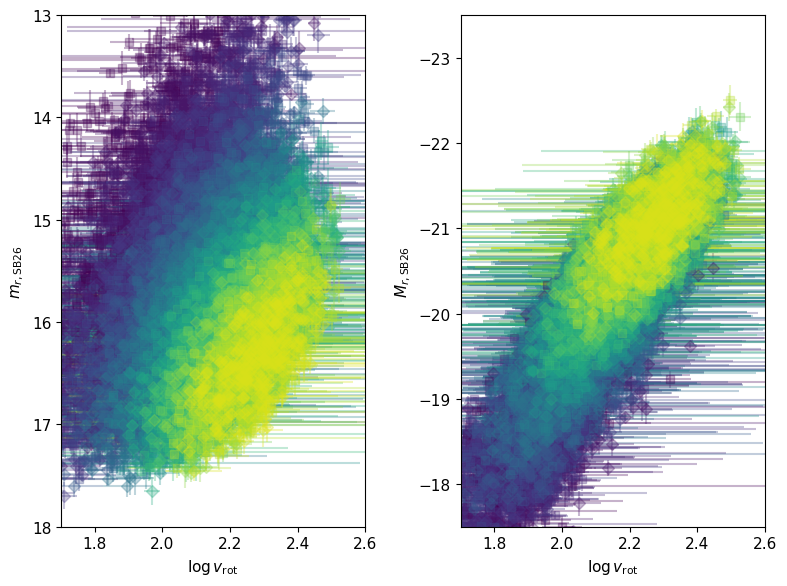

In [53]:
fig, axes = plt.subplots(1,2, figsize=(8,6), sharex=True, tight_layout=True)

# logV0 = 0

_zbin_ids = np.sort(np.unique(zbin_idx))
n_zbins = len(_zbin_ids)

markers = 'sDv^<>'

colors = iter(plt.cm.viridis(np.linspace(0,1, n_zbins + 1)))

for j, _zbin_id in enumerate(_zbin_ids):
    select_zbin = np.isin(zbin_idx, _zbin_id)

    logv = mock_downsample['LOGVROT_MOCK'][select_zbin] #- logV0
    logv_err = mock_downsample['LOGVROT_ERR_MOCK'][select_zbin]

    mr26 = mock_downsample['R_MAG_SB26_CORR'][select_zbin]
    mr26_err = mock_downsample['R_MAG_SB26_ERR_CORR'][select_zbin]

    Mr26 = mock_downsample['R_ABSMAG_SB26_MOCK'][select_zbin]
    Mr26_err = mock_downsample['R_ABSMAG_SB26_ERR_MOCK'][select_zbin]

    c = next(colors)

    ax = axes[0]
    ax.errorbar(x=logv, y=mr26, xerr=logv_err, yerr=mr26_err,
                fmt=markers[j % 2], markersize=6, alpha=0.3,
                color=c)

    ax = axes[1]
    ax.errorbar(x=logv, y=Mr26, xerr=logv_err, yerr=Mr26_err,
                fmt=markers[j % 2], markersize=6, alpha=0.3,
                color=c)

ax = axes[0]
ax.set(xlim=(1.7, 2.6),
       ylim=(18, 13),
       xlabel=r'$\log{v_\mathrm{rot}}$',
       ylabel=r'$m_{r,\mathrm{SB26}}$')

ax = axes[1]
ax.set(ylim=(-17.5, -23.5),
       xlabel=r'$\log{v_\mathrm{rot}}$',
       ylabel=r'$M_{r,\mathrm{SB26}}$');

#### Pack the Data and Fit with `MultiLinFit`

In [54]:
bounds = [[-20, 0]]              # Bounds on a (slope)
bounds += n_zbins*[(-20, 20)]    # Bounds on b (intercepts: z-bins)
bounds += [(0,5)]                # Bounds on sigma

# logV0_mock = np.median(mock_downsample['LOGVROT_MOCK'])
# print(logV0_mock)
print(logV0)

datasets = [] # list of (2xN) arrays of the data
covs = []     # covariance of zero point and slope for each "cluster"

for j, _zbin_id in enumerate(_zbin_ids):
    select_zbin = np.isin(zbin_idx, _zbin_id)

    logv = mock_downsample['LOGVROT_MOCK'].to_numpy()[select_zbin] - logV0
    dlogv = mock_downsample['LOGVROT_ERR_MOCK'].to_numpy()[select_zbin]
    mr = mock_downsample['R_MAG_SB26_CORR'].to_numpy()[select_zbin]
    dmr = mock_downsample['R_MAG_SB26_ERR_CORR'].to_numpy()[select_zbin]

    N = len(logv)
    cov = np.empty((2, 2, N))
    for i in range(N):
        cov[:,:,i] = np.array([[dlogv[i]**2, 0.], [0., dmr[i]**2]])
    covs.append(cov)

    data = np.empty((2, N))
    data[0] = logv
    data[1] = mr
    datasets.append(data)

hf = MultiLinFit(datasets, covs, scatter=1)
pars, parscatter, lnpost = hf.optimize(bounds)

2.1667289487278083


In [55]:
pars, parscatter

(array([-7.17443124, 12.7189507 , 13.41446098, 13.94725377, 14.33430883,
        14.69586413, 15.0260168 , 15.27652799, 15.51079629, 15.76985455,
        15.9596421 , 16.15170991, 16.32768691, 16.50731542, 16.65904486,
        16.81331174, 16.91705103, 17.07347671, 17.17162856]),
 array([0.4104996]))

#### Try the Fit using MCMC

In [56]:
## Use logV0 from data so we can directly compare the zero points
# Pack the calibration set into lists
logv, dlogv = [], []
mr, dmr = [], []
weights = []

# Loop over redshift bins
for j, _zbin_id in enumerate(_zbin_ids):
    select_zbin = np.isin(zbin_idx, _zbin_id)

    logv.append(mock_downsample['LOGVROT_MOCK'].to_numpy()[select_zbin] - logV0)
    dlogv.append(mock_downsample['LOGVROT_ERR_MOCK'].to_numpy()[select_zbin])
    mr.append(mock_downsample['R_MAG_SB26_CORR'].to_numpy()[select_zbin])
    dmr.append(mock_downsample['R_MAG_SB26_ERR_CORR'].to_numpy()[select_zbin])
    weights.append(np.ones_like(mock_downsample['LOGVROT_MOCK'][select_zbin]))

In [57]:
# Number of redshift bins
bounds = [[-20, 0]]        # Bounds on a (slope)
bounds += n_zbins*[(-20, 20)]    # Bounds on b (intercepts: z-bins)
bounds += [(0,5)]          # Bounds on sigma

# logging.warning('Fit does not account for volume weights.')

results = hyperfit_line_multi(logv, mr, dlogv, dmr, bounds, weights=weights, scatter=1)

a_mcmc, b_mcmc, sigma_mcmc, cov_mcmc, mcmc_samples, hf = results
sigma_mcmc = sigma_mcmc.item()

             message: Optimization terminated successfully.
             success: True
                 fun: -36395.4000259194
                   x: [-7.173e+00  1.272e+01 ...  1.717e+01  4.104e-01]
                 nit: 193
                nfev: 58431
          population: [[-7.172e+00  1.272e+01 ...  1.717e+01  4.102e-01]
                       [-7.174e+00  1.272e+01 ...  1.718e+01  4.102e-01]
                       ...
                       [-7.171e+00  1.272e+01 ...  1.718e+01  4.105e-01]
                       [-7.170e+00  1.272e+01 ...  1.717e+01  4.107e-01]]
 population_energies: [-3.640e+04 -3.640e+04 ... -3.640e+04 -3.640e+04]
                 jac: [ 5.894e-01  6.839e-02 ...  8.513e-02  1.056e+00]
Ndim: 20 18


100%|██████████████████████████████████████████| 1000/1000 [00:26<00:00, 37.42it/s]


Niterations/Max Iterations:  1000 / 100000
Integrated ACT/Min Convergence Iterations:  [75.5579479  81.32264873 85.8873518  84.55553258 78.18257976 86.19051069
 88.1621508  79.89077658 84.7905171  78.03046719 82.47222336 78.51079959
 85.67026267 78.32830544 85.3632443  83.06890983 81.89860189 77.8397472
 84.85673337 75.61826643] / 4408.107539812634


100%|██████████████████████████████████████████| 1000/1000 [00:26<00:00, 37.42it/s]


Niterations/Max Iterations:  2000 / 100000
Integrated ACT/Min Convergence Iterations:  [102.52208451 108.50611832 105.20633286 111.41003828 108.84674506
 103.82589419 109.80555302 106.19647701  93.60068685 100.42789853
 107.71661086 102.97921594 106.52972135 103.02854431  93.54741279
  93.69455239 105.86139966 100.4797557  105.51480216 104.57271472] / 5570.501913846723


...

Niterations/Max Iterations:  21000 / 100000
Integrated ACT/Min Convergence Iterations:  [261.75982636 237.57949545 239.8087366  244.97913091 248.13185537
 248.21086076 257.7875314  253.05179815 218.3815989  250.57666575
 254.0997406  262.87964511 257.39631234 250.04324724 237.83862674
 245.54381013 239.48674541 236.53767816 227.42125659 234.99589397] / 13143.982255307508


100%|██████████████████████████████████████████| 1000/1000 [00:26<00:00, 37.32it/s]


Niterations/Max Iterations:  22000 / 100000
Integrated ACT/Min Convergence Iterations:  [269.88639594 252.66432067 233.79043759 244.11713166 247.96271915
 254.09013618 263.49779415 248.49820833 224.59083789 250.9067888
 250.09071366 264.021258   263.67344702 256.32677264 235.92057535
 245.95582722 236.40073707 238.15545387 235.72561237 239.890233  ] / 13494.3197968558


100%|██████████████████████████████████████████| 1000/1000 [00:26<00:00, 37.62it/s]


Niterations/Max Iterations:  23000 / 100000
Integrated ACT/Min Convergence Iterations:  [266.13049564 255.59085049 231.65320941 246.97482894 247.48125483
 265.1902406  261.08151883 256.35366514 224.57589581 254.46476968
 254.79415492 255.84680257 264.28331489 258.96883298 241.19450654
 250.76824891 235.67317172 240.22858099 236.0507063  237.63538391] / 13306.52478215363


#### Plot the HyperFit Results

In [58]:
m = len(logv)
values = np.median(mcmc_samples, axis=1)
sigmas = np.sqrt(np.diag(cov_mcmc))

multiple = 3.5

limits = []

for i in range(len(values)):
    limits.append([values[i] - multiple*sigmas[i], 
                   values[i] + multiple*sigmas[i]])

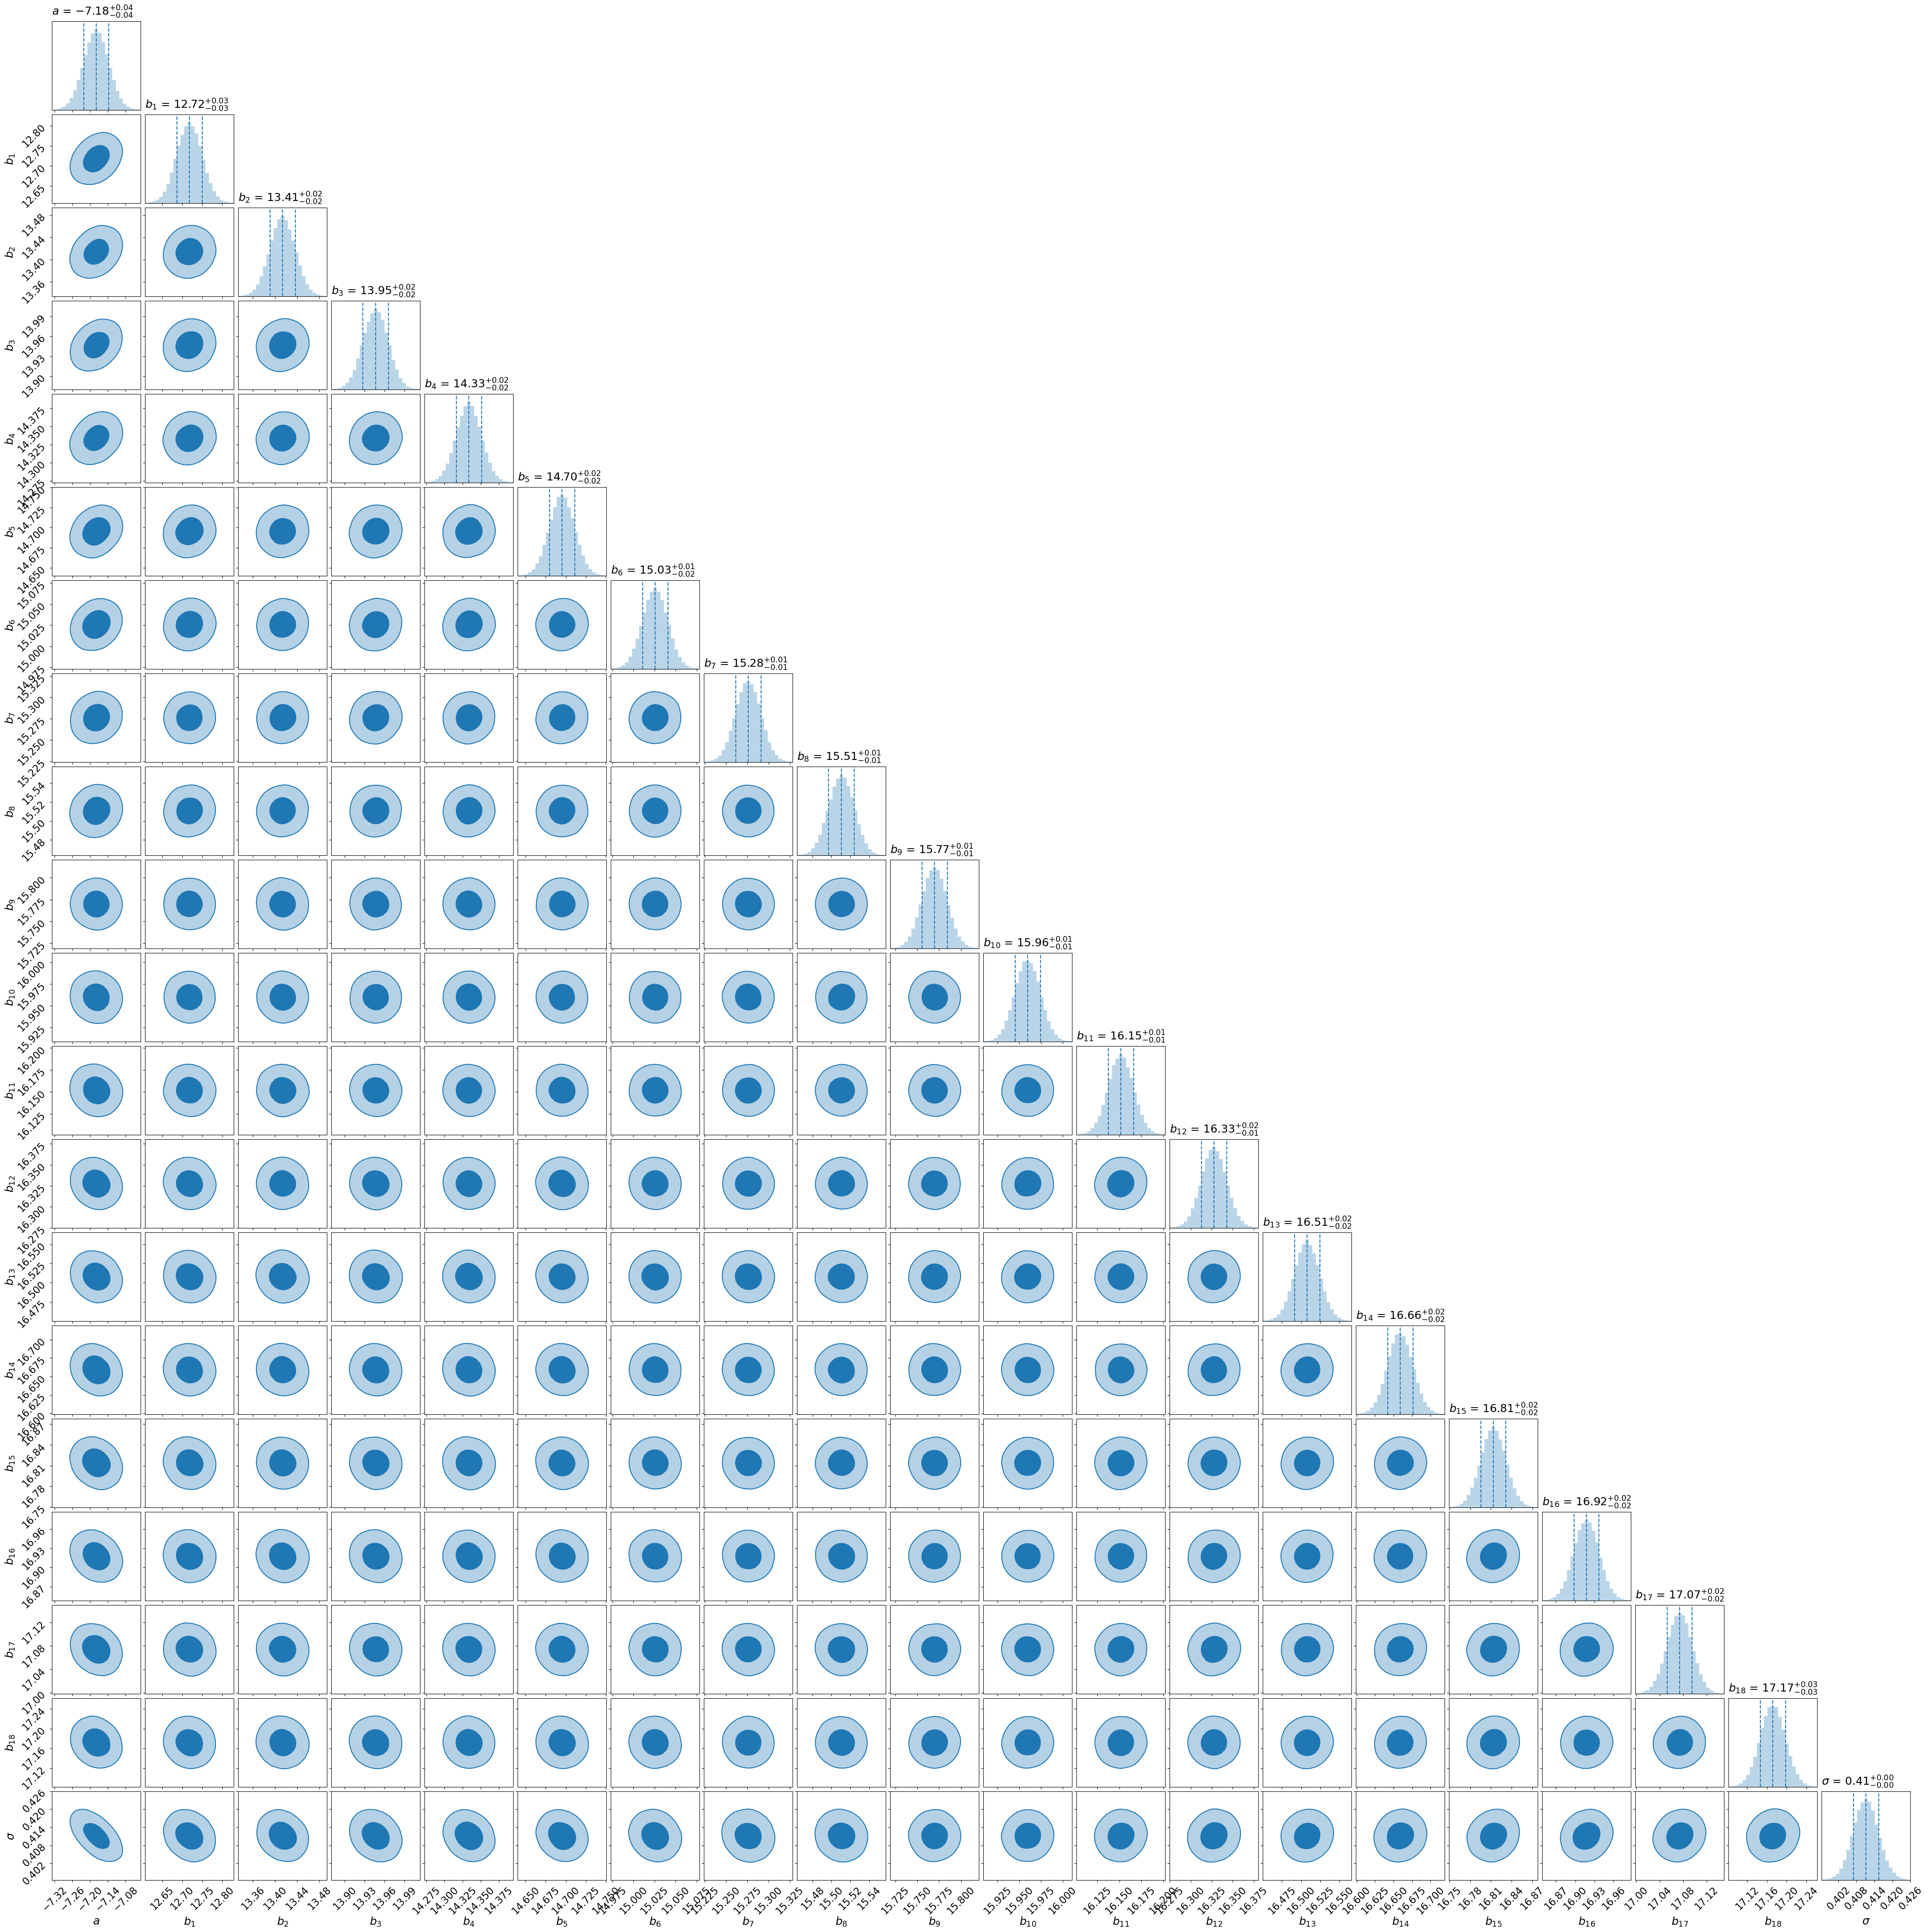

In [59]:
labels  = ['$a$']
labels += [f'$b_{{ {k+1} }}$' for k in np.arange(m)]
labels += [r'$\sigma$']

fig = corner(mcmc_samples.T, bins=25, smooth=1,
             range=limits,
             labels=labels,
             label_kwargs={'fontsize':18},
             labelpad=0.1,
             levels=(1-np.exp(-0.5), 1-np.exp(-2)),
             quantiles=[0.16, 0.5, 0.84],
             color='tab:blue',
             hist_kwargs={'histtype':'stepfilled', 'alpha':0.3},
             plot_datapoints=False,
             fill_contours=True,
             # truths=tf_par,
             truth_color='tab:green',
             show_titles=True,
             title_kwargs={"fontsize": 18, 'loc':'left', 'pad':10});

for ax in fig.get_axes():
    ax.tick_params(axis='both', which='major', labelsize=16);

# fig.savefig('tfr_mock_calibration_mcmc.png', dpi=150)

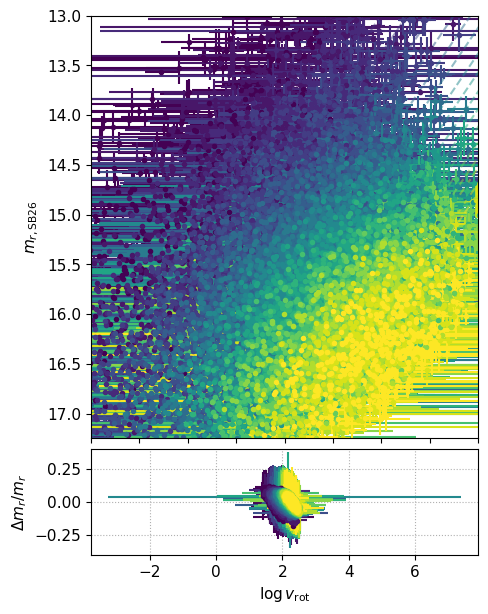

In [60]:
fig, axes = plt.subplots(2, 1, figsize=(5,7),
                         gridspec_kw={'height_ratios':[4,1], 'hspace':0.04, 'wspace':0.25})

_logv = np.arange(0, 3, 0.1) - logV0

color = iter(plt.cm.viridis(np.linspace(0,1, n_zbins)))

for k in range(n_zbins):
    ax = axes[0]
    c = next(color)
    
    eb = ax.errorbar(x=logv[k] + logV0, y=mr[k],
                     xerr=dlogv[k], yerr=dmr[k],
                     fmt='.', color=c,
                     label=f'{zbins[k]:.3f}-{zbins[k+1]:.3f}')

    ax.plot(_logv + logV0, a_mcmc*_logv + b_mcmc[k], color=eb[0].get_color(), ls='--', alpha=0.5)

    ax = axes[1]
    logv_obs = logv[k]
    m_obs = mr[k]
    m_exp = a_mcmc*logv_obs + b_mcmc[k]
    eb = ax.errorbar(x=logv_obs + logV0, y=(m_exp - m_obs)/m_exp,
                     xerr=dlogv[k], yerr=dmr[k],
                     fmt='.', color=c)

ax = axes[0]
ax.set(xlim=[1.7, 2.5],
       ylim=[17.25, 13],
       xticklabels=[],
       ylabel=r'$m_{r,\mathrm{SB26}}$')

ax = axes[1]
ax.grid(ls=':')

ax.set(xlabel=r'$\log{v_\mathrm{rot}}$',
       ylabel=r'$\Delta m_r/m_r$',
       ylim=(-0.4,0.4));

<>:16: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:16: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/var/folders/_q/fz6mqjy17zz9cs9ng5q0hq_m0000gq/T/ipykernel_43192/2850124609.py:16: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  axes[row,col].set(xlim=[1.6, 2.6], ylim=[18.5, 11], title=f'{zbins[i]:.3f} < z $\leq$ {zbins[i+1]:.3f}')


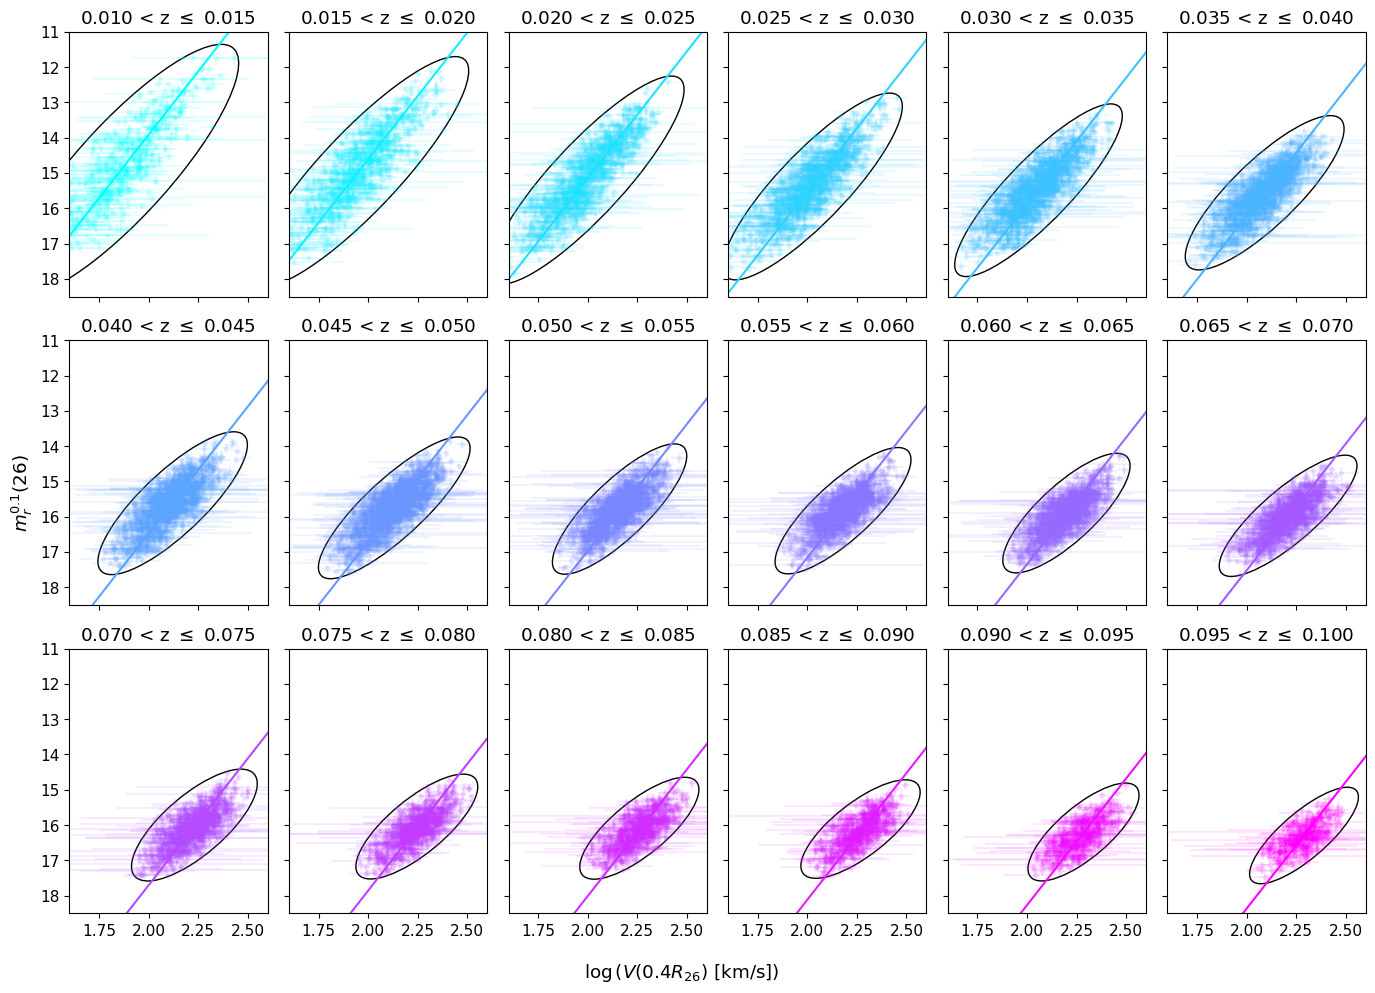

In [61]:
fig, axes = plt.subplots(nrows=3, ncols=6, sharex=True, sharey=True, figsize=(14,10), tight_layout=True)

color = iter(plt.cm.cool(np.linspace(0,1, n_zbins)))
for i in range(n_zbins):
    c = next(color)
    
    row = int(i/6)
    col = i%6
    
    eb = axes[row,col].errorbar(logv[i] + logV0, mr[i], xerr=dlogv[i], yerr=dmr[i], fmt='.', color=c, alpha=0.1)
    axes[row,col].plot(_logv + logV0, a_mcmc*_logv + b_mcmc[i], color=c)
    # axes[row,col].plot(_logv + logV0, a*_logv + b[i], 'k--', zorder=20)
    plot_ellipse(mean = [ellipse_params[i+1][0], ellipse_params[i+1][1]],cov = [[ellipse_params[i+1][2], ellipse_params[i+1][3]],[ellipse_params[i+1][4],ellipse_params[i+1][5]]],
                 n_std = ellipse_sigma, ax=axes[row,col], edgecolor='k', facecolor='none')
    
    axes[row,col].set(xlim=[1.6, 2.6], ylim=[18.5, 11], title=f'{zbins[i]:.3f} < z $\leq$ {zbins[i+1]:.3f}')


# Delete extra axes
# fig.delaxes(axs[-1,-1])

fig.supxlabel(r'$\log{(V(0.4R_{26})~[\mathrm{km/s}]}$)')
fig.supylabel(r'$m_r^{0.1} (26)$');

#### Quick Check of Many Realizations of the "Calibration" Sample

In [62]:
# bounds = [[-20, 0]]              # Bounds on a (slope)
# bounds += n_zbins*[(-20, 20)]    # Bounds on b (intercepts: z-bins)
# bounds += [(0,5)]                # Bounds on sigma

# a_real, b_real, sigma_real = [], [], []

# for i in tqdm(np.arange(25)):
#     mock_downsample = downsample(mock, Ntfr)
    
#     idx_mock_downsample_good = mag_ellipse_boolean(mock_downsample['zobs'], mock_downsample['LOGVROT_MOCK'], mock_downsample['R_MAG_SB26_CORR'],
#                                     ellipse_params, n_std=ellipse_sigma, absmag_cat=mock_downsample['R_ABSMAG_SB26_MOCK'])

#     zbin_idx = np.digitize(mock_downsample['zobs'], zbins, right=True)
#     no_use = (zbin_idx == 0) | (zbin_idx == len(zbins))
#     mock_downsample = downsample(mock_downsample[idx_mock_downsample_good & ~no_use], size=Ntfr_cal)
    
#     zbin_idx = np.digitize(mock_downsample['zobs'], zbins, right=True)

#     datasets = [] # list of (2xN) arrays of the data
#     covs = []     # covariance of zero point and slope for each "cluster"
    
#     for j, _zbin_id in enumerate(_zbin_ids):
#         select_zbin = np.isin(zbin_idx, _zbin_id)
    
#         logv = mock_downsample['LOGVROT_MOCK'].to_numpy()[select_zbin] - logV0
#         dlogv = mock_downsample['LOGVROT_ERR_MOCK'].to_numpy()[select_zbin]
#         mr = mock_downsample['R_MAG_SB26_CORR'].to_numpy()[select_zbin]
#         dmr = mock_downsample['R_MAG_SB26_ERR_CORR'].to_numpy()[select_zbin]
    
#         N = len(logv)
#         cov = np.empty((2, 2, N))
#         for k in range(N):
#             cov[:,:,k] = np.array([[dlogv[k]**2, 0.], [0., dmr[k]**2]])
#         covs.append(cov)
    
#         data = np.empty((2, N))
#         data[0] = logv
#         data[1] = mr
#         datasets.append(data)
    
#     hf = MultiLinFit(datasets, covs, scatter=1)
#     pars, parscatter, lnpost = hf.optimize(bounds)

#     a_real.append(pars[0])
#     b_real.append(pars[1:])
#     sigma_real.append(parscatter[0])

In [63]:
# fig, axes = plt.subplots(1,3, figsize=(12,4), tight_layout=True)

# ax = axes[0]
# ax.hist(a_real, bins=np.arange(-8.5,-6.4,0.1))
# # ax.axvline(tf_par[0], color='tab:orange', ls='--')
# ax.axvline(np.mean(a_real), color='tab:green')
# ax.axvline(np.mean(a_real) - np.std(a_real), color='tab:green', ls='--')
# ax.axvline(np.mean(a_real) + np.std(a_real), color='tab:green', ls='--')
# ax.set(title=rf'$\hat{{a}}={np.mean(a_real):.2f}\pm{np.std(a_real):.2f}$',
#        xlabel=r'slope $a$')

# ax = axes[1]
# ax.hist(b_real[0], bins=np.arange(10,20.4,0.4))
# # ax.axvline(tf_par[1], color='tab:orange', ls='--')
# ax.axvline(np.mean(b_real[0]), color='tab:green')
# ax.axvline(np.mean(b_real[0]) - np.std(b_real[0]), color='tab:green', ls='--')
# ax.axvline(np.mean(b_real[0]) + np.std(b_real[0]), color='tab:green', ls='--')
# ax.set(title=rf'$\hat{{b}}_0={np.mean(b_real[0]):.2f}\pm{np.std(b_real):.2f}$',
#        xlabel=r'zero point $b_1$')

# ax = axes[2]
# ax.hist(sigma_real, bins=np.arange(0.4,0.71,0.01))
# # ax.axvline(tf_par[-1], color='tab:orange', ls='--')
# ax.axvline(np.mean(sigma_real), color='tab:green')
# ax.axvline(np.mean(sigma_real) - np.std(sigma_real), color='tab:green', ls='--')
# ax.axvline(np.mean(sigma_real) + np.std(sigma_real), color='tab:green', ls='--')
# ax.set(title=rf'$\hat{{\sigma}}={np.mean(sigma_real):.2f}\pm{np.std(sigma_real):.2f}$',
#        xlabel=r'magnitude scatter $\sigma$')

# # fig.set_facecolor('none')
# # fig.savefig(f'tfr_fit_param_spread_equal_weight_{os.path.basename(mockfile)[:-9]}.png', dpi=150)
# # # fig.savefig('tfr_fit_param_spread_error_weighted.png', dpi=150)
# # # fig.savefig('tfr_fit_param_spread_var_weighted.png', dpi=150)

In [64]:
# a_avg = np.average(a_real)
# b_avg = np.average(b_real, axis=0)
# sigma_avg = np.average(sigma_real)
# a_avg, b_avg, sigma_avg

In [65]:
# a_mcmc, b_mcmc, sigma_mcmc = a_avg, b_avg, sigma_avg

#### Apply Velocity and Dwarf Identification to the Full Sample

In [66]:
idx_mock_good = mag_ellipse_boolean(mock['zobs'], mock['LOGVROT_MOCK'], mock['R_MAG_SB26_CORR'],
                                    ellipse_params, n_std=ellipse_sigma, absmag_cat=mock['R_ABSMAG_SB26_MOCK'])

mock['DWARF'] = np.zeros_like(mock['LOGVROT_MOCK'], dtype=bool)
mock.loc[~idx_mock_good, 'DWARF'] = True

mock['MAIN'] = np.zeros_like(mock['DWARF'], dtype=bool)
mock.loc[idx_mock_good, 'MAIN'] = True

In [67]:
# mock_main = mock['MAIN']
# mock_dwarfs = mock['DWARF']

In [68]:
len(mock), np.sum(mock['MAIN']) 

(177184, np.int64(162247))

In [69]:
# Identify zbins for all mock galaxies
zbin_idx = np.digitize(mock['zobs'], zbins, right=True)

### Compute TFR Distance Modulus

Using the "measured" apparent magnitude and the TFR-predicted absolute magnitude from the "calibration" above, compute the distance modulus:

$$
\mu_\mathrm{TF} =  m_{r,\mathrm{SB_{26}}} - M_{r,\mathrm{TF}}.
$$

Also compute the log distance ratio

$$
\eta = \log{\left(\frac{D_z}{D_\mathrm{TFR}}\right)}
$$

In [70]:
#- Compute TF absolute magnitude and uncertainties using the MCMC from HyperFit.
#  Downsample the MCMC significantly for this quick calculation.

# Redshift bin centers:
zc = 0.5*dz + zbins[:-1]
mu_zc = cosmology.distmod(zc)

# Convert each redshift bin zero point to an abs mag
B_mcmc = b_mcmc - mu_zc.value

# Compute indices for intercepts.
# For galaxies outside the calibration range, assign them to the closest bin.
B_idx = zbin_idx - 1
B_idx[zbin_idx == 0] = 0
B_idx[zbin_idx == len(zbins)] = len(zbins) - 2

# Store mcmc variations for slopes and intercepts
idx = np.random.default_rng().choice(mcmc_samples.shape[1], size=1000, replace=False)
slopes = mcmc_samples[0, idx]
ZPs = mcmc_samples[1:-1, idx] - mu_zc[:,None].value

# Use the calibrated TFR to compute abs mag.
logV0_mock = np.median(mock['LOGVROT_MOCK'])
Mr_TF = a_mcmc * (mock['LOGVROT_MOCK'] - logV0) + B_mcmc[B_idx]

# Compute the uncertainty in TFR abs mag.
Mr_TF_err = np.zeros_like(Mr_TF)

V = 10**mock['LOGVROT_MOCK']
V_err = (1/0.434) * V * mock['LOGVROT_ERR_MOCK']

for i in tqdm(range(len(mock))):
    v_random = np.random.normal(V.iloc[i], V_err.iloc[i], size=1000)
    v_random_good = v_random[v_random > 0]
    logv_random = np.random.normal(mock['LOGVROT_MOCK'].iloc[i], mock['LOGVROT_ERR_MOCK'].iloc[i], size=1000)
    
    # Mr_stat = a_mcmc*(logv_random - logV0) + B_mcmc[B_idx[i]]
    # Mr_TF_err[i] = np.sqrt(np.nanstd(Mr_stat)**2 + sigma_mcmc**2)
    Ms = slopes[v_random > 0]*(np.log10(v_random_good) - logV0) + ZPs[B_idx[i],v_random > 0]
    Mr_TF_err[i] = np.sqrt(np.nanstd(Ms)**2 + sigma_mcmc**2)

# Mr_TF = a_mcmc * (logvrot_mock - logV0_mock) + b_mcmc
# a_sampled, b_sampled = mcmc_samples[0][::500], mcmc_samples[1][::500]
# Mr_TF_err = np.std(a_sampled * (logvrot_mock[:, np.newaxis] - logV0_mock) + b_sampled, axis=1)

mu_TF = mock['R_MAG_SB26_CORR'] - Mr_TF
mu_TF_err = np.sqrt(mock['R_ABSMAG_SB26_ERR_MOCK']**2 + Mr_TF_err**2)

mu_zcmb = cosmology.distmod(mock['zobs']).to_value('mag')
mu_zcos = cosmology.distmod(mock['zcos']).to_value('mag')

eta_true = 0.2 * (mu_zcmb - mu_zcos)
eta_mock = 0.2 * (mu_zcmb - mu_TF)
eta_err_mock = 0.2 * mu_TF_err

100%|███████████████████████████████████| 177184/177184 [00:12<00:00, 13703.54it/s]


### Sanity Checks

#### Check Trends of $\eta$ with Redshift: Data

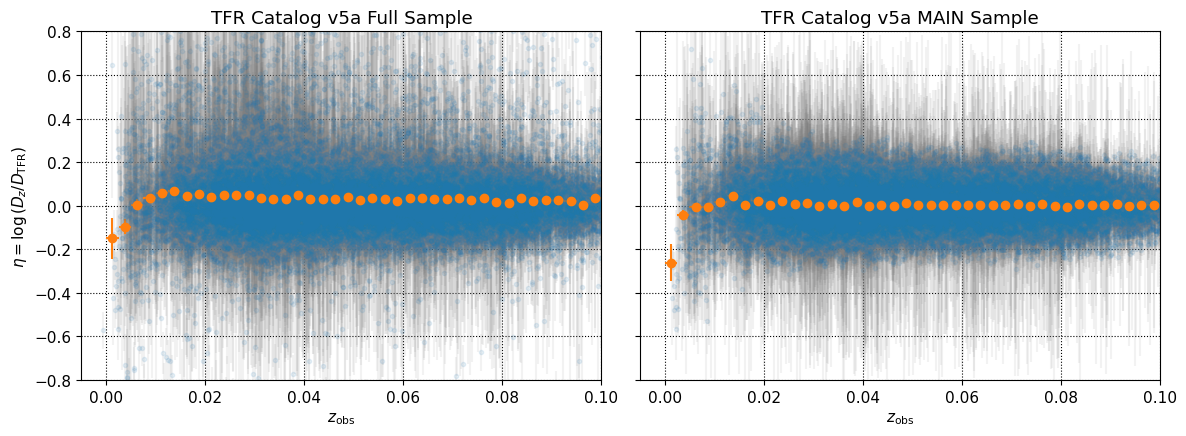

In [71]:
fig, axes = plt.subplots(1,2, figsize=(12,4.5), sharex=True, sharey=True, tight_layout=True)

ax = axes[0]
ax.errorbar(tfrcat['Z_DESI_CMB'], tfrcat['LOGDIST'],
            yerr=tfrcat['LOGDIST_ERR'],
            fmt='.',
            alpha=0.1,
            ecolor='gray')

zbins = np.arange(0, 0.1025, 0.0025)
dz = 0.5*np.diff(zbins)
zc = 0.5*(zbins[1:] + zbins[:-1])

_, eta_avg, eta_std = profile_histogram(tfrcat['Z_DESI_CMB'], tfrcat['LOGDIST'], zbins)
ax.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='tab:orange')

ax.set(xlabel=r'$z_\mathrm{obs}$',
       xlim=(-0.005,0.1),
       ylim=(-0.8,0.8),
       ylabel=r'$\eta = \log{(D_z / D_\mathrm{TFR})}$',
       title=f'TFR Catalog {tfr_version} Full Sample')
ax.grid(ls=':', color='k')

ax = axes[1]
select = tfrcat['MAIN']
ax.errorbar(tfrcat['Z_DESI_CMB'][select], tfrcat['LOGDIST'][select],
            yerr=tfrcat['LOGDIST_ERR'][select],
            fmt='.',
            alpha=0.1,
            ecolor='gray')

zbins = np.arange(0, 0.1025, 0.0025)
dz = 0.5*np.diff(zbins)
zc = 0.5*(zbins[1:] + zbins[:-1])

_, eta_avg, eta_std = profile_histogram(tfrcat['Z_DESI_CMB'][select], tfrcat['LOGDIST'][select], zbins)
ax.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='tab:orange')

ax.set(xlabel=r'$z_\mathrm{obs}$',
       title=f'TFR Catalog {tfr_version} MAIN Sample')
ax.grid(ls=':', color='k')

fig.set_facecolor('none')
# fig.savefig('tfr_mock_eta.png', dpi=150);

#### Check Trends of $\eta$ with Redshift: Mocks

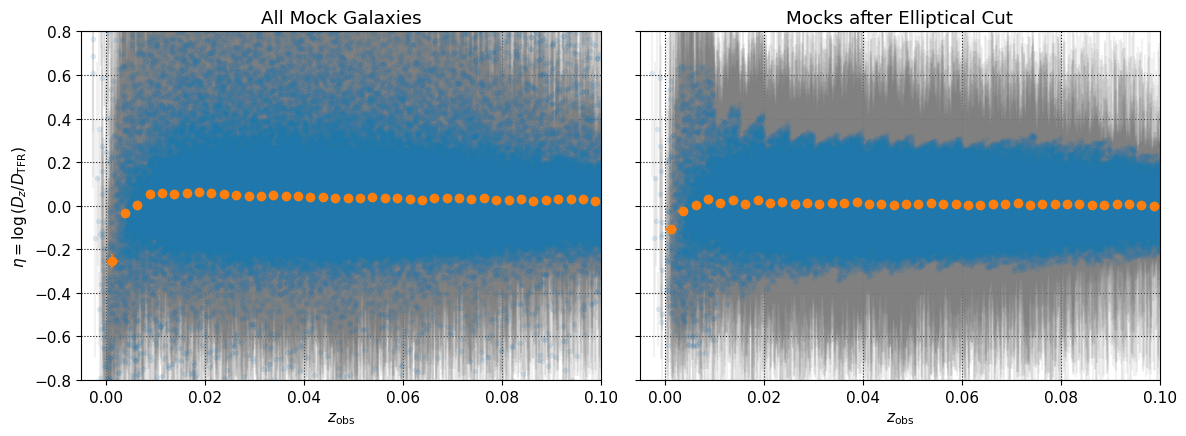

In [72]:
fig, axes = plt.subplots(1,2, figsize=(12,4.5), sharex=True, sharey=True, tight_layout=True)

ax = axes[0]
ax.errorbar(mock['zobs'], eta_mock,
            yerr=eta_err_mock,
            fmt='.',
            alpha=0.1,
            ecolor='gray')

zbins = np.arange(0, 0.1025, 0.0025)
dz = 0.5*np.diff(zbins)
zc = 0.5*(zbins[1:] + zbins[:-1])

_, eta_avg, eta_std = profile_histogram(mock['zobs'], eta_mock, zbins)
ax.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='tab:orange')

ax.set(xlabel=r'$z_\mathrm{obs}$',
       xlim=(-0.005,0.1),
       ylim=(-0.8,0.8),
       ylabel=r'$\eta = \log{(D_z / D_\mathrm{TFR})}$',
       title='All Mock Galaxies')
ax.grid(ls=':', color='k')

ax = axes[1]
ax.errorbar(mock['zobs'][idx_mock_good], eta_mock[idx_mock_good],
            yerr=eta_err_mock[idx_mock_good],
            fmt='.',
            alpha=0.1,
            ecolor='gray')

zbins = np.arange(0, 0.1025, 0.0025)
dz = 0.5*np.diff(zbins)
zc = 0.5*(zbins[1:] + zbins[:-1])

_, eta_avg, eta_std = profile_histogram(mock['zobs'][idx_mock_good], eta_mock[idx_mock_good], zbins)
ax.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='tab:orange')

ax.set(xlabel=r'$z_\mathrm{obs}$',
       title='Mocks after Elliptical Cut')
ax.grid(ls=':', color='k')

fig.set_facecolor('none')
# fig.savefig('tfr_mock_eta.png', dpi=150);

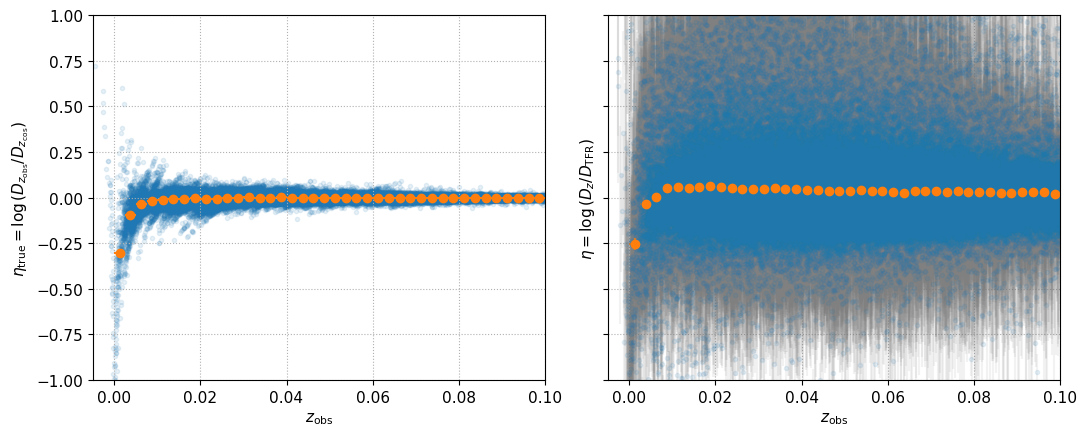

In [73]:
fig, axes = plt.subplots(1,2, figsize=(11,4.5), tight_layout=True, sharex=True, sharey=True)

ax = axes[0]
ax.scatter(mock['zobs'], eta_true, marker='.', alpha=0.1)

ax = axes[1]
ax.errorbar(mock['zobs'], eta_mock, yerr=eta_err_mock, fmt='.', alpha=0.1, ecolor='gray')

zbins = np.arange(0, 0.1025, 0.0025)
dz = 0.5*np.diff(zbins)
zc = 0.5*(zbins[1:] + zbins[:-1])

ax = axes[0]
_, eta_avg, eta_std = profile_histogram(mock['zobs'], eta_true, zbins)
ax.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='tab:orange')
ax.set(xlabel=r'$z_\mathrm{obs}$',
       xlim=(-0.005,0.1),
       ylim=(-1,1),
       ylabel=r'$\eta_\mathrm{true} = \log{(D_{z_\mathrm{obs}} / D_{z_\mathrm{cos}})}$')
ax.grid(ls=':')

ax = axes[1]
_, eta_avg, eta_std = profile_histogram(mock['zobs'], eta_mock, zbins)
ax.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='tab:orange')
ax.set(xlabel=r'$z_\mathrm{obs}$',
       xlim=(-0.005,0.1),
       ylim=(-1,1),
       ylabel=r'$\eta = \log{(D_z / D_\mathrm{TFR})}$')
ax.grid(ls=':');

fig.set_facecolor('none')
# fig.savefig('tfr_mock_eta_true_mock.png', dpi=150);

#### Check that $\eta_\mathrm{mock}$ Tracks $\eta_\mathrm{true}$

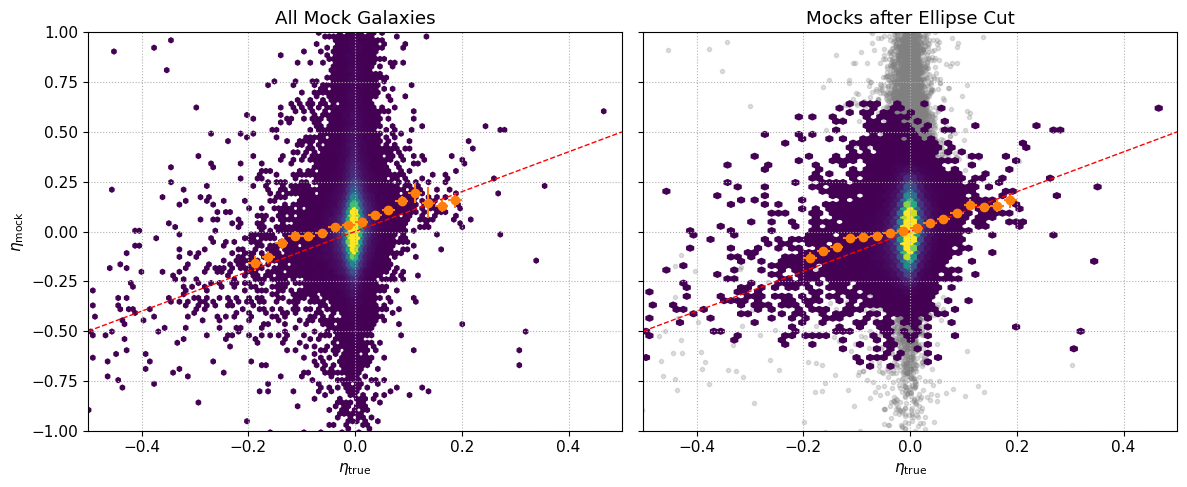

In [74]:
fig, axes = plt.subplots(1,2, figsize=(12,5),  sharex=True, sharey=True, tight_layout=True)

#- Draw the full distribution
ax = axes[0]
ax.hexbin(eta_true, eta_mock, cmap='viridis', mincnt=1, vmin=1, vmax=2e3, gridsize=(300,100))

eta_bins = np.arange(-0.2, 0.225, 0.025)
eta_c = 0.5*(eta_bins[1:] + eta_bins[:-1])
deta = 0.5*np.diff(eta_bins)
_, eta_avg, eta_std = profile_histogram(eta_true, eta_mock, eta_bins)

ax.errorbar(eta_c, eta_avg, xerr=deta, yerr=eta_std, fmt='o', color='tab:orange')

ax.set(xlim=(-0.5,0.5),
       xlabel=r'$\eta_\mathrm{true}$',
       ylim=(-1,1),
       ylabel=r'$\eta_\mathrm{mock}$',
       title='All Mock Galaxies')

#- Plot a 1:1 line
_eta = np.arange(-0.5, 0.51, 0.01)
ax.plot(_eta, _eta, lw=1, ls='--', color='red')
ax.grid(ls=':');

#- Remove galaxies that do not pass the ellipse cut
ax = axes[1]
ax.scatter(eta_true[~idx_mock_good], eta_mock[~idx_mock_good], marker='.', color='gray', alpha=0.25)
ax.hexbin(eta_true[idx_mock_good], eta_mock[idx_mock_good], cmap='viridis', mincnt=1, vmin=1, vmax=3e3, gridsize=(100,30))

eta_bins = np.arange(-0.2, 0.225, 0.025)
eta_c = 0.5*(eta_bins[1:] + eta_bins[:-1])
deta = 0.5*np.diff(eta_bins)
_, eta_avg, eta_std = profile_histogram(eta_true[idx_mock_good], eta_mock[idx_mock_good], eta_bins)

ax.errorbar(eta_c, eta_avg, xerr=deta, yerr=eta_std, fmt='o', color='tab:orange')

ax.set(xlabel=r'$\eta_\mathrm{true}$',
       title='Mocks after Ellipse Cut')

#- Plot a 1:1 line
_eta = np.arange(-0.5, 0.51, 0.01)
ax.plot(_eta, _eta, lw=1, ls='--', color='red')
ax.grid(ls=':');

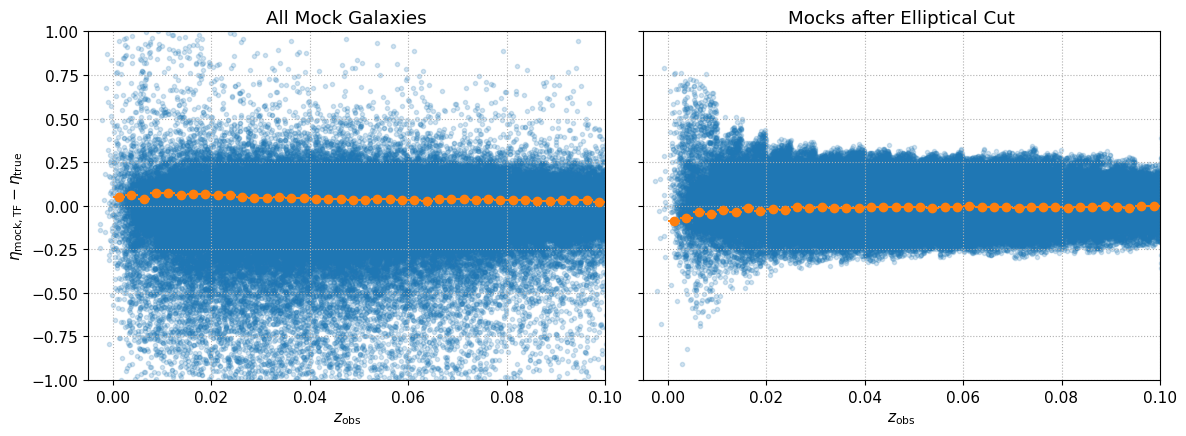

In [75]:
fig, axes = plt.subplots(1,2, figsize=(12,4.5), sharex=True, sharey=True, tight_layout=True)

ax = axes[0]
ax.scatter(mock['zobs'], eta_true - eta_mock, alpha=0.2, marker='.')

_, deta_avg, deta_std = profile_histogram(mock['zobs'], eta_mock - eta_true, zbins)
ax.errorbar(zc, deta_avg, xerr=dz, yerr=deta_std, fmt='o', color='tab:orange')

ax.set(xlabel=r'$z_\mathrm{obs}$',
       xlim=(-0.005,0.1),
       ylim=(-1,1),
       ylabel=r'$\eta_\mathrm{mock,TF} - \eta_\mathrm{true}$',
       title='All Mock Galaxies')
ax.grid(ls=':')

ax = axes[1]
ax.scatter(mock['zobs'][idx_mock_good], eta_mock[idx_mock_good] - eta_true[idx_mock_good], alpha=0.2, marker='.')

_, deta_avg, deta_std = profile_histogram(mock['zobs'][idx_mock_good], eta_true[idx_mock_good] - eta_mock[idx_mock_good], zbins)
ax.errorbar(zc, deta_avg, xerr=dz, yerr=deta_std, fmt='o', color='tab:orange')

ax.set(xlabel=r'$z_\mathrm{obs}$',
       title='Mocks after Elliptical Cut')
ax.grid(ls=':');

#### Check the Pull Distribution

Look at the pull $\Delta\eta/\sigma_\eta$, where $\Delta\eta=\eta_\mathrm{mock,TF} - \eta_\mathrm{true}$.

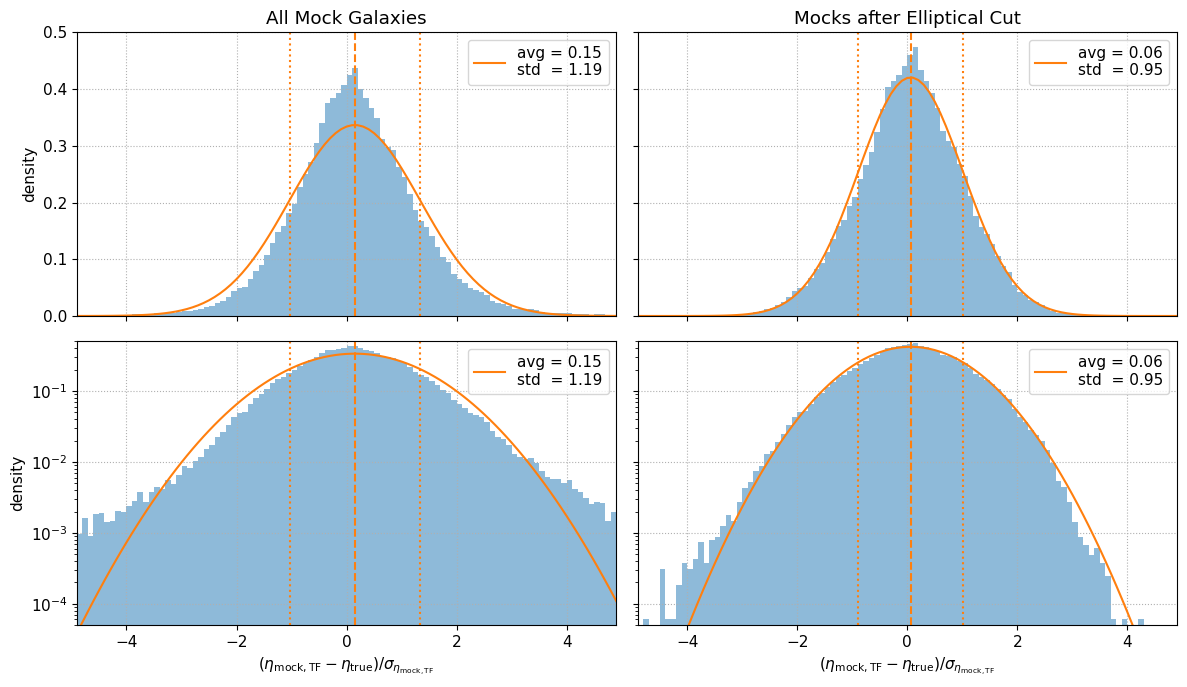

In [76]:
fig, axes = plt.subplots(2,2, figsize=(12,7), sharex=True, tight_layout=True)

eta_bins = np.arange(-4.9, 5, 0.1)

for j in [0,1]:
    ax = axes[j,0]
    pull_full = (eta_mock - eta_true) / eta_err_mock
    mu, std = norm.fit(pull_full)
    
    ax.hist(pull_full, bins=eta_bins, density=True, alpha=0.5)
    ax.set(xlabel=r'$(\eta_\mathrm{mock,TF} - \eta_\mathrm{true})/\sigma_{\eta_\mathrm{mock,TF}}$' if j==1 else None,
           xlim=eta_bins[[0,-1]],
           ylabel='density',
           ylim=(5e-5, 0.5) if j==1 else (0,0.5),
           yscale='log' if j==1 else 'linear',
           title='All Mock Galaxies' if j==0 else None)
    
    mu, std = norm.fit(pull_full)
    pdf = norm.pdf(eta_bins, loc=mu, scale=std)
    ax.plot(eta_bins, pdf, label=f'avg = {mu:.2f}\nstd  = {std:.2f}')
    for _a in [-1, 0, 1]:
        ax.axvline(mu + _a*std, ls='--' if _a==0 else ':', color='tab:orange')
    ax.legend(loc='upper right', fontsize=11)
    ax.grid(ls=':')
    
    ax = axes[j,1]
    pull_cuts = (eta_mock[idx_mock_good] - eta_true[idx_mock_good]) / eta_err_mock[idx_mock_good]
    mu, std = norm.fit(pull_cuts)
    
    ax.hist(pull_cuts, bins=eta_bins, density=True, alpha=0.5)
    ax.set(xlabel=r'$(\eta_\mathrm{mock,TF} - \eta_\mathrm{true})/\sigma_{\eta_\mathrm{mock,TF}}$' if j==1 else None,
           yscale='log' if j==1 else 'linear',
           ylim=(5e-5, 0.5) if j==1 else (0,0.5),
           yticklabels=[],
           title='Mocks after Elliptical Cut' if j==0 else None)
    
    pdf = norm.pdf(eta_bins, loc=mu, scale=std)
    ax.plot(eta_bins, pdf, label=f'avg = {mu:.2f}\nstd  = {std:.2f}')
    for _a in [-1, 0, 1]:
        ax.axvline(mu + _a*std, ls='--' if _a==0 else ':', color='tab:orange')
    ax.legend(loc='upper right', fontsize=11)
    ax.grid(ls=':');

#### Compare $\eta$ in Mock vs Data

Note: the ellipse cut in the TFR catalog is denoted by the `MAIN` column.

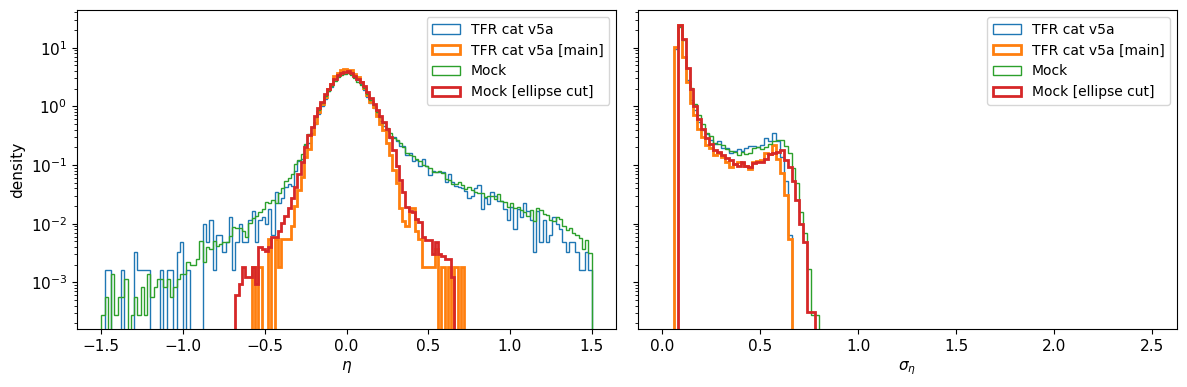

In [77]:
fig, axes = plt.subplots(1,2, figsize=(12,4), sharey=True, tight_layout=True)

#- Compare eta between data and mock
ax = axes[0]
eta_bins=np.arange(-1.5, 1.52, 0.02)
ax.hist(tfrcat['LOGDIST'], bins=eta_bins, histtype='step', density=True, label=f'TFR cat {tfr_version}')
ax.hist(tfrcat['LOGDIST'][tfrcat['MAIN']], bins=eta_bins, lw=2, histtype='step', density=True, label=f'TFR cat {tfr_version} [main]')

ax.hist(eta_mock, bins=eta_bins, lw=1, histtype='step', density=True, label='Mock')
ax.hist(eta_mock[idx_mock_good], bins=eta_bins, lw=2, histtype='step', density=True, label='Mock [ellipse cut]')
ax.set(yscale='log',
       ylabel='density',
       xlabel=r'$\eta$')

ax.legend(fontsize=10)

#- Compare eta_err between data and mock
ax = axes[1]
eta_bins=np.arange(0, 2.52, 0.02)
ax.hist(tfrcat['LOGDIST_ERR'], bins=eta_bins, histtype='step', density=True, label=f'TFR cat {tfr_version}')
ax.hist(tfrcat['LOGDIST_ERR'][tfrcat['MAIN']], bins=eta_bins, lw=2, histtype='step', density=True, label=f'TFR cat {tfr_version} [main]')

ax.hist(eta_err_mock, bins=eta_bins, lw=1, histtype='step', density=True, label='Mock')
ax.hist(eta_err_mock[idx_mock_good], bins=eta_bins, lw=2, histtype='step', density=True, label='Mock [ellipse cut]')
ax.set(xlabel=r'$\sigma_\eta$')

ax.legend(fontsize=10);

## Redshift Dependence

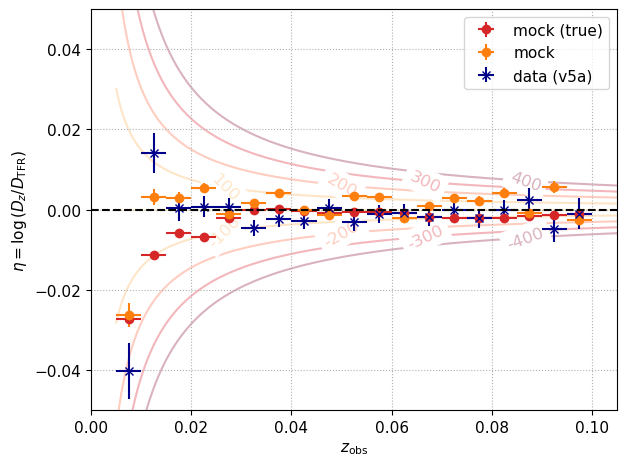

In [78]:
fig = plt.figure(tight_layout=True)

_zbins = np.arange(0, 0.105, 0.005)
dz = 0.5*np.diff(_zbins)
zc = 0.5*(_zbins[1:] + _zbins[:-1])


plt.grid(ls=':')

# True mock
_, eta_avg, eta_std = profile_histogram(mock['zobs'][mock['MAIN']], 
                                        eta_true[mock['MAIN']], 
                                        _zbins)
plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='tab:red', label='mock (true)')

# Mock
_, eta_avg, eta_std = profile_histogram(mock['zobs'][mock['MAIN']], 
                                        eta_mock[mock['MAIN']], 
                                        _zbins, 
                                        weights=eta_err_mock[mock['MAIN']]**-2, 
                                        weighted=True)
plt.errorbar(zc, eta_avg, xerr=dz, yerr=eta_std, fmt='o', color='tab:orange', label='mock')

# Data
_, data_eta_avg, data_eta_std = profile_histogram(tfrcat['Z_DESI'][tfrcat['MAIN']], 
                                                  tfrcat['LOGDIST'][tfrcat['MAIN']], 
                                                  _zbins, 
                                                  weights=tfrcat['LOGDIST_ERR'][tfrcat['MAIN']]**-2, 
                                                  weighted=True)
plt.errorbar(zc, data_eta_avg, xerr=dz, yerr=data_eta_std, fmt='x', color='darkblue', label=f'data ({tfr_version})')

#-------------------------------------------------------------------------------
# PV lines (code taken from Cullen)
#-------------------------------------------------------------------------------
LightSpeed = const.c.to('km/s').value
velarray = np.arange(-400, 401, 100)
zarray = np.linspace(0.005, 0.11, 200)

dzarray = cosmology.comoving_distance(zarray).value
dharray = cosmology.comoving_distance(np.outer(1.0/(1.0 + velarray/LightSpeed), 
    								  (1.0 + zarray)) - 1.0).value
deltamarray = np.log10(dzarray/dharray)

rotation = [20.0, 25.0, 30.0, 45.0, 0.0, -45.0, -30.0, -25.0, -20.0]
labels = ["-400", "-300", "-200", "-100", "0", "100", "200", "300", "400"]
xcoord = np.array([26000.0, 20000.0, 15000.0, 8000.0, -1000.0, 8000.0, 15000.0, 20000.0, 26000.0])
coord = np.searchsorted(zarray, xcoord/LightSpeed)
ycoord = np.array([deltamarray[i,j] for i, j in enumerate(coord)])

colors = 0.8*np.fabs(velarray)/np.amax(np.fabs(velarray)) + 0.2

for v in range(len(velarray)):
    c = plt.cm.YlOrRd(colors[v])

    plt.plot(zarray, deltamarray[v,:], 
             color=c, 
             linestyle='-', 
             alpha=0.3, 
             zorder=0)

    if (v != 4):
        plt.text(xcoord[v]/LightSpeed, ycoord[v], 
                 labels[v], 
                 color=c, 
                 fontsize=12, 
                 rotation=rotation[v], 
                 ha="center", 
                 va="center", 
                 bbox=dict(boxstyle="square", ec="w", fc="w"), 
                 zorder=1, 
                 alpha=0.3)

# Line at eta = 0
plt.hlines(0, 0, 0.2, linestyles='dashed', colors='k', zorder=5)
#-------------------------------------------------------------------------------

plt.legend()

plt.xlabel(r'$z_\mathrm{obs}$')
plt.ylabel(r'$\eta = \log{(D_z / D_\mathrm{TFR})}$')

plt.xlim(0,0.105)
plt.ylim(-0.05, 0.05);

# fig.savefig('tfr_mock_eta.png', dpi=150);

### Redshift distributions

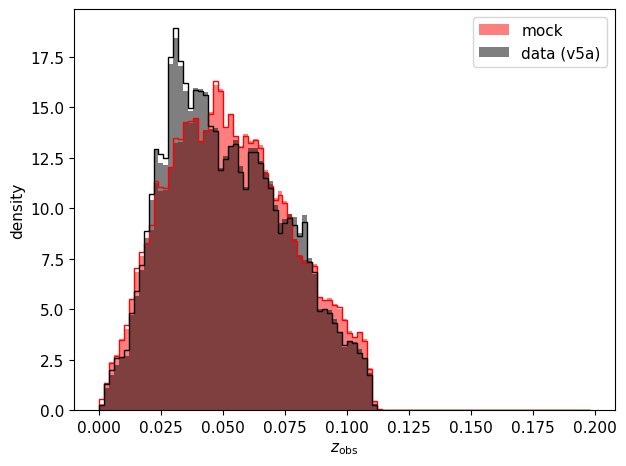

In [79]:
plt.figure(tight_layout=True)

_zbins = np.arange(0, 0.2, 0.002)

# Mocks
plt.hist(mock['zobs'], bins=_zbins, density=True, color='r', histtype='step')
plt.hist(mock['zobs'][mock['MAIN']], bins=_zbins, density=True, color='r', alpha=0.5, label='mock')

# Data
plt.hist(tfrcat['Z_DESI'], bins=_zbins, density=True, color='k', histtype='step')
plt.hist(tfrcat['Z_DESI'][tfrcat['MAIN']], bins=_zbins, density=True, color='k', alpha=0.5, label=f'data ({tfr_version})')

plt.legend()

plt.xlabel(r'$z_\mathrm{obs}$')
plt.ylabel('density');

## Other Correlations

### Log Distance vs Log Rotational Velocity

<>:11: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:24: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:11: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:24: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
/var/folders/_q/fz6mqjy17zz9cs9ng5q0hq_m0000gq/T/ipykernel_43192/2334451063.py:11: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  ylabel='$\eta_{true}$',
/var/folders/_q/fz6mqjy17zz9cs9ng5q0hq_m0000gq/T/ipykernel_43192/2334451063.py:24: SyntaxWarning: "\e" is an invalid escape sequ

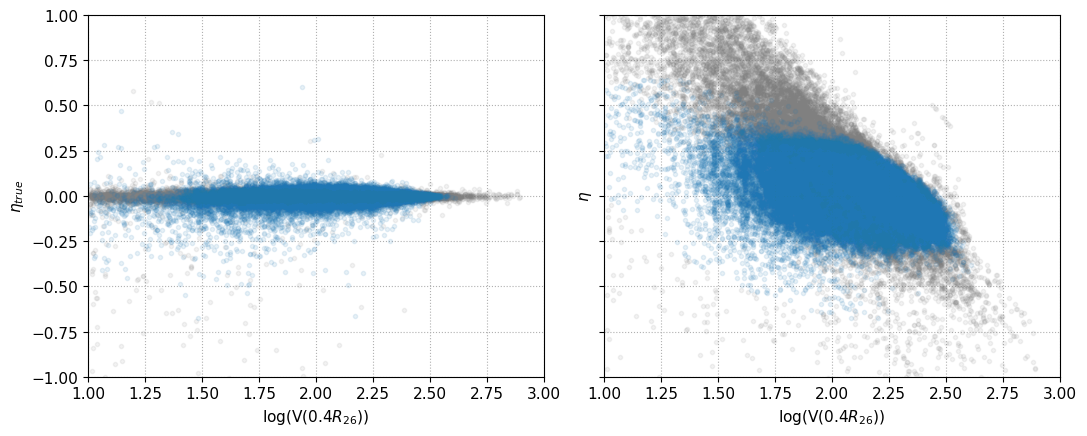

In [80]:
fig, axes = plt.subplots(1,2, figsize=(11,4.5), tight_layout=True, sharex=True, sharey=True)

# Truth
ax = axes[0]
ax.plot(logvrot_mock[~mock['MAIN']], eta_true[~mock['MAIN']], '.', alpha=0.1, c='gray')
ax.plot(logvrot_mock[mock['MAIN']], eta_true[mock['MAIN']], '.', alpha=0.1)

ax.grid(ls=':')

ax.set(xlabel='log(V(0.4$R_{26}$))', 
       ylabel='$\eta_{true}$', 
       ylim=(-1, 1), 
       xlim=(1,3))


# Mock (generated)
ax = axes[1]
ax.plot(logvrot_mock[~mock['MAIN']], eta_mock[~mock['MAIN']], '.', alpha=0.1, c='gray')
ax.plot(logvrot_mock[mock['MAIN']], eta_mock[mock['MAIN']], '.', alpha=0.1)

ax.grid(ls=':')

ax.set(xlabel='log(V(0.4$R_{26}$))', 
       ylabel='$\eta$');

<>:29: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:29: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
/var/folders/_q/fz6mqjy17zz9cs9ng5q0hq_m0000gq/T/ipykernel_43192/3133780177.py:29: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  plt.ylabel('$\eta_{obs} - \eta_{true}$');
/var/folders/_q/fz6mqjy17zz9cs9ng5q0hq_m0000gq/T/ipykernel_43192/2152062125.py:69: RuntimeWarning: invalid value encountered in divide
  e = np.sqrt((mean2 - mean**2) / (N - 1))


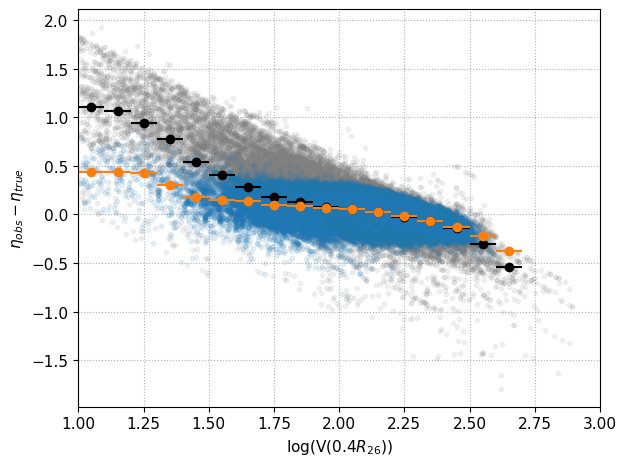

In [81]:
logv_bins = np.arange(1, 2.75, 0.1)
dv = 0.5*np.diff(logv_bins)
vc = 0.5*(logv_bins[1:] + logv_bins[:-1])

plt.figure(tight_layout=True)

plt.plot(logvrot_mock[~mock['MAIN']], 
         eta_mock[~mock['MAIN']] - eta_true[~mock['MAIN']], 
         '.', c='gray', alpha=0.1)

plt.plot(logvrot_mock[mock['MAIN']], 
         eta_mock[mock['MAIN']] - eta_true[mock['MAIN']], 
         '.', c='tab:blue', alpha=0.1)

_, dn_avg, dn_std = profile_histogram(logvrot_mock, eta_mock - eta_true, logv_bins, median=True)
plt.errorbar(vc, dn_avg, xerr=dv, yerr=dn_std, fmt='o', color='black')

_, dn_avg, dn_std = profile_histogram(logvrot_mock[mock['MAIN']], 
                                      eta_mock[mock['MAIN']] - eta_true[mock['MAIN']], 
                                      logv_bins, 
                                      median=True)
plt.errorbar(vc, dn_avg, xerr=dv, yerr=dn_std, fmt='o', color='tab:orange')

plt.grid(ls=':')

plt.xlim((1,3))

plt.xlabel('log(V(0.4$R_{26}$))')
plt.ylabel('$\eta_{obs} - \eta_{true}$');

### Log Distance vs Absolute r-band Magnitude

<>:44: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:44: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
/var/folders/_q/fz6mqjy17zz9cs9ng5q0hq_m0000gq/T/ipykernel_43192/306801859.py:44: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  plt.ylabel('$\eta_{obs} - \eta_{true}$');


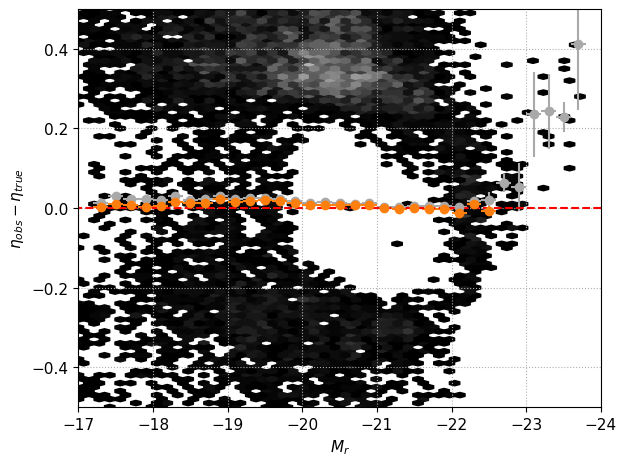

In [82]:
Mr_bins = np.arange(-24, -17, 0.2)
dMr = 0.5*np.diff(Mr_bins)
Mrc = 0.5*(Mr_bins[1:] + Mr_bins[:-1])

plt.figure(tight_layout=True)

plt.hexbin(mock['R_ABSMAG_SB26_MOCK'][~mock['MAIN']], 
           eta_mock[~mock['MAIN']] - eta_true[~mock['MAIN']], 
           cmap='Greys_r', 
           vmin=1, 
           vmax=50, 
           mincnt=1, 
           gridsize=(50, 50), 
           extent=(-24, -17, -0.5, 0.5))

# plt.hexbin(mock['R_ABSMAG_SB26_MOCK'][mock_main], 
#            eta_mock[mock_main] - eta_true[mock_main], 
#            cmap='viridis', 
#            vmin=1, 
#            vmax=400, 
#            mincnt=1, 
#            gridsize=(50, 50), 
#            extent=(-24, -17, -0.5, 0.5))

_, dn_avg, dn_std = profile_histogram(mock['R_ABSMAG_SB26_MOCK'], 
                                      eta_mock - eta_true, 
                                      Mr_bins, median=True)
plt.errorbar(Mrc, dn_avg, xerr=dMr, yerr=dn_std, fmt='o', color='darkgrey')

_, dn_avg, dn_std = profile_histogram(mock['R_ABSMAG_SB26_MOCK'][mock['MAIN']], 
                                      eta_mock[mock['MAIN']] - eta_true[mock['MAIN']], 
                                      Mr_bins, 
                                      median=True)
plt.errorbar(Mrc, dn_avg, xerr=dMr, yerr=dn_std, fmt='o', color='tab:orange')

plt.hlines(0, -24, -17, linestyles='dashed', colors='r')

plt.grid(ls=':')

plt.xlim((-17,-24))
plt.ylim(-0.5, 0.5)

plt.xlabel('$M_r$')
plt.ylabel('$\eta_{obs} - \eta_{true}$');

### Log Distance / Redshift Correlation

<>:44: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:44: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
/var/folders/_q/fz6mqjy17zz9cs9ng5q0hq_m0000gq/T/ipykernel_43192/1248181388.py:44: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  plt.ylabel('$\eta_{obs} - \eta_{true}$');
/var/folders/_q/fz6mqjy17zz9cs9ng5q0hq_m0000gq/T/ipykernel_43192/2152062125.py:69: RuntimeWarning: invalid value encountered in divide
  e = np.sqrt((mean2 - mean**2) / (N - 1))


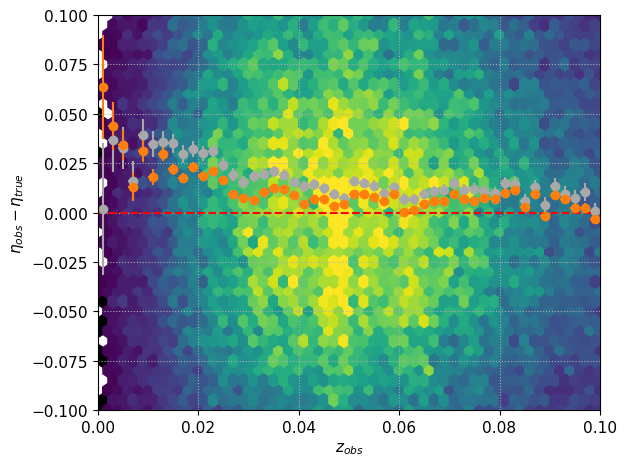

In [83]:
_zbins = np.arange(0, 0.2, 0.002)
dz = 0.5*np.diff(_zbins)
zc = 0.5*(_zbins[1:] + _zbins[:-1])

plt.figure(tight_layout=True)

plt.hexbin(mock['zobs'][~mock['MAIN']], 
           eta_mock[~mock['MAIN']] - eta_true[~mock['MAIN']], 
           cmap='Greys_r', 
           vmin=1, 
           vmax=50, 
           mincnt=1, 
           gridsize=(50, 100), 
           extent=(0, 0.1, -0.5, 0.5))

plt.hexbin(mock['zobs'][mock['MAIN']], 
           eta_mock[mock['MAIN']] - eta_true[mock['MAIN']], 
           cmap='viridis', 
           vmin=1, 
           vmax=100, 
           mincnt=1, 
           gridsize=(50, 100), 
           extent=(0, 0.1, -0.5, 0.5))

_, dn_avg, dn_std = profile_histogram(mock['zobs'], 
                                      eta_mock - eta_true, 
                                      _zbins, median=True)
plt.errorbar(zc, dn_avg, xerr=dz, yerr=dn_std, fmt='o', color='darkgrey')

_, dn_avg, dn_std = profile_histogram(mock['zobs'][mock['MAIN']], 
                                      eta_mock[mock['MAIN']] - eta_true[mock['MAIN']], 
                                      _zbins, 
                                      median=True)
plt.errorbar(zc, dn_avg, xerr=dz, yerr=dn_std, fmt='o', color='tab:orange')

plt.hlines(0, 0, 0.1, linestyles='dashed', colors='r')

plt.grid(ls=':')

plt.xlim(0, 0.1)
plt.ylim(-0.1, 0.1)

plt.xlabel('$z_{obs}$')
plt.ylabel('$\eta_{obs} - \eta_{true}$');

## Write Output to FITS

In [84]:
{ 'a' : a_mcmc} | \
{ f'b{k+1}' : b_mcmc[k] for k in range(len(b_mcmc)) } | \
{ 'sigma' : sigma_mcmc } | \
{ 'ell_std' : ellipse_sigma }

{'a': np.float64(-7.178721884955239),
 'b1': np.float64(12.718068049835523),
 'b2': np.float64(13.41361632215116),
 'b3': np.float64(13.946622735772213),
 'b4': np.float64(14.333722267688536),
 'b5': np.float64(14.695339468104338),
 'b6': np.float64(15.025723879500159),
 'b7': np.float64(15.276182598791957),
 'b8': np.float64(15.510700188719612),
 'b9': np.float64(15.769797899561734),
 'b10': np.float64(15.959785259745656),
 'b11': np.float64(16.151767053949513),
 'b12': np.float64(16.327755135417885),
 'b13': np.float64(16.507845402445376),
 'b14': np.float64(16.659177110404414),
 'b15': np.float64(16.81369000795425),
 'b16': np.float64(16.917759143732596),
 'b17': np.float64(17.07424137209977),
 'b18': np.float64(17.172137248856554),
 'sigma': 0.41121965058460563,
 'ell_std': 2.86}

In [85]:
outfile = os.path.join(pvpath, f'mocks/DR2/TF_mocks/full_mocks/{mock_version}.{mock_subversion}',
                       os.path.basename(mockfile).replace('.dat.hdf5', '.fits').replace('BGS_PV', 'TF'))

os.makedirs(os.path.dirname(outfile), exist_ok=True)

outfile

'/Users/sbenzvi/Documents/DESI/pv/mocks/DR2/TF_mocks/full_mocks/v2.0.8/TF_AbacusSummit_base_c000_ph000_r000_zsnap0.20_zmax0.11.fits'

In [86]:
# hdr = fits.Header(dict(NTF=len(mock),
#                        a=a_mcmc,
#                        b=b_mcmc,
#                        sigma=sigma_mcmc,
#                        cov_aa=cov_mcmc[0][0],
#                        cov_ab=cov_mcmc[0][1],
#                        cov_as=cov_mcmc[0][2],
#                        cov_bb=cov_mcmc[1][1],
#                        cov_bs=cov_mcmc[1][2],
#                        cov_ss=cov_mcmc[2][2]))

hdr = fits.Header({ 'NTF' : len(mock) } | \
                  { 'a' : a_mcmc } | \
                  { f'b{k+1}' : b_mcmc[k] for k in range(len(b_mcmc)) } | \
                  { 'sigma' : sigma_mcmc} | \
                  { 'elpsstd' : ellipse_sigma } | \
                  { f'CFF{band}' : A_int_coeff[band][0] for band in 'GRZ' } | \
                  { f'CFF{band}_ERR' : A_int_coeff_err[band][0] for band in 'GRZ' } )      

col01 = fits.Column(name='RA',                 format='D', array=mock['ra'].to_numpy())
col02 = fits.Column(name='DEC',                format='D', array=mock['dec'].to_numpy())
col03 = fits.Column(name='ZOBS',               format='D', array=mock['zobs'].to_numpy())
col04 = fits.Column(name='ZCOS',               format='D', array=mock['zcos'].to_numpy())
col05 = fits.Column(name='vx',                 format='D', array=mock['vx'].to_numpy())
col06 = fits.Column(name='vy',                 format='D', array=mock['vy'].to_numpy())
col07 = fits.Column(name='vz',                 format='D', array=mock['vz'].to_numpy())
col08 = fits.Column(name='DWARF',              format='L', array=mock['DWARF'].to_numpy())
col09 = fits.Column(name='MAIN',               format='L', array=mock['MAIN'].to_numpy())
col10 = fits.Column(name='BA_RATIO',           format='D', array=mock['BA_ratio'].to_numpy())
col11 = fits.Column(name='PHOTSYS',            format='D', array=mock['A_SYS'].to_numpy())
col12 = fits.Column(name='PHOTSYS_ERR',        format='D', array=mock['A_SYS_ERR'].to_numpy())
col13 = fits.Column(name='A_INT_G',            format='D', array=mock['A_INT_G'].to_numpy())
col14 = fits.Column(name='A_INT_ERR_G',        format='D', array=mock['A_INT_ERR_G'].to_numpy())
col15 = fits.Column(name='A_INT_R',            format='D', array=mock['A_INT_R'].to_numpy())
col16 = fits.Column(name='A_INT_ERR_R',        format='D', array=mock['A_INT_ERR_R'].to_numpy())
col17 = fits.Column(name='A_INT_Z',            format='D', array=mock['A_INT_Z'].to_numpy())
col18 = fits.Column(name='A_INT_ERR_Z',        format='D', array=mock['A_INT_ERR_Z'].to_numpy())
col19 = fits.Column(name='LOGVROT',            format='D', array=mock['LOGVROT_MOCK'].to_numpy())
col20 = fits.Column(name='LOGVROT_ERR',        format='D', array=mock['LOGVROT_ERR_MOCK'].to_numpy())
col21 = fits.Column(name='G_MAG_SB26' ,        format='D', array=mock['G_MAG_SB26'].to_numpy())
col22 = fits.Column(name='G_MAG_SB26_ERR',     format='D', array=mock['G_MAG_SB26_ERR'].to_numpy())
col23 = fits.Column(name='R_MAG_SB26' ,        format='D', array=mock['R_MAG_SB26'].to_numpy())
col24 = fits.Column(name='R_MAG_SB26_ERR',     format='D', array=mock['R_MAG_SB26_ERR'].to_numpy())
col25 = fits.Column(name='Z_MAG_SB26' ,        format='D', array=mock['Z_MAG_SB26'].to_numpy())
col26 = fits.Column(name='Z_MAG_SB26_ERR',     format='D', array=mock['Z_MAG_SB26_ERR'].to_numpy())
col27 = fits.Column(name='G_ABSMAG_SB26' ,     format='D', array=mock['G_ABSMAG_SB26_MOCK'].to_numpy())
col28 = fits.Column(name='G_ABSMAG_SB26_ERR',  format='D', array=mock['G_ABSMAG_SB26_ERR_MOCK'].to_numpy())
col29 = fits.Column(name='G_ABSMAG_SB26_TRUE', format='D', array=mock['G_ABSMAG_SB26_TRUE'].to_numpy())
col30 = fits.Column(name='R_ABSMAG_SB26' ,     format='D', array=mock['R_ABSMAG_SB26_MOCK'].to_numpy())
col31 = fits.Column(name='R_ABSMAG_SB26_ERR',  format='D', array=mock['R_ABSMAG_SB26_ERR_MOCK'].to_numpy())
col32 = fits.Column(name='R_ABSMAG_SB26_TRUE', format='D', array=mock['R_ABSMAG_SB26_TRUE'].to_numpy())
col33 = fits.Column(name='Z_ABSMAG_SB26' ,     format='D', array=mock['Z_ABSMAG_SB26_MOCK'].to_numpy())
col34 = fits.Column(name='Z_ABSMAG_SB26_ERR',  format='D', array=mock['Z_ABSMAG_SB26_ERR_MOCK'].to_numpy())
col35 = fits.Column(name='Z_ABSMAG_SB26_TRUE', format='D', array=mock['Z_ABSMAG_SB26_TRUE'].to_numpy())
col36 = fits.Column(name='LOGDIST_TRUE',       format='D', array=eta_true)
col37 = fits.Column(name='LOGDIST',            format='D', array=eta_mock.to_numpy())
col38 = fits.Column(name='LOGDIST_ERR',        format='D', array=eta_err_mock.to_numpy())
col39 = fits.Column(name='Y1_COMP',            format='D', array=mock['Y1_COMP'].to_numpy())
col40 = fits.Column(name='Y3_COMP',            format='D', array=mock['Y3_COMP'].to_numpy())

hdulist = fits.BinTableHDU.from_columns([col01, col02, col03, col04, col05,
                                         col06, col07, col08, col09, col10,
                                         col11, col12, col13, col14, col15,
                                         col16, col17, col18, col19, col20,
                                         col21, col22, col23, col24, col25,
                                         col26, col27, col28, col29, col30,
                                         col31, col32, col33, col34, col35,
                                         col36, col37, col38, col39, col40],
                                        header=hdr)
hdulist.writeto(outfile, overwrite=True)

# shutil.chown(outfile, group='desi')

In [87]:
mock.keys()

Index(['Y1_COMP', 'Y3_COMP', 'Y5', 'abs_mag', 'app_mag', 'col', 'col_obs',
       'dec', 'halo_ind', 'halo_mass', 'healpix', 'is_cen', 'is_res',
       'program', 'ra', 'survey', 'targetid', 'vx', 'vy', 'vz', 'zcos', 'zobs',
       'target_dec', 'target_ra', 'z', 'zerr', 'zwarn', 'morphtype', 'sersic',
       'mag_g', 'mag_g_err', 'mag_r', 'mag_r_err', 'mag_z', 'mag_z_err',
       'uncor_radius', 'BA_ratio', 'circ_radius', 'circ_radius_err', 'SGA_id',
       'radius_SB25', 'inbasiccuts', 'has_corrupt_phot', 'deltachi2', 'SGA_ra',
       'SGA_dec', 'BA', 'D26', 'G_MAG_SB26', 'G_MAG_SB26_ERR', 'R_MAG_SB26',
       'R_MAG_SB26_ERR', 'Z_MAG_SB26', 'Z_MAG_SB26_ERR', 'photsys', 'A_SYS',
       'A_SYS_ERR', 'G_MAG_SB26_tmp', 'G_MAG_SB26_ERR_tmp', 'R_MAG_SB26_tmp',
       'R_MAG_SB26_ERR_tmp', 'Z_MAG_SB26_tmp', 'Z_MAG_SB26_ERR_tmp',
       'G_MAG_SB26_CORR', 'G_MAG_SB26_ERR_CORR', 'A_INT_G', 'A_INT_ERR_G',
       'R_MAG_SB26_CORR', 'R_MAG_SB26_ERR_CORR', 'A_INT_R', 'A_INT_ERR_R',
       'Z_MAG

In [88]:
# !jupyter nbconvert --to script TFR_DR2_mock_gen.ipynb